# Week 5 Exercises — Report

**Course:** Data-Driven Methods  
**Author:** Dimitris Papantzikos  
**Date:** March 5, 2026

---

## Abstract
Briefly summarize the goals, methods, and key findings (3–5 sentences).

# Exercise 2.3 — KdV Equation via FFT

## Problem Statement
Use the FFT to solve the Korteweg–de Vries (KdV) equation,

$$u_t + u_{xxx} - u u_x = 0,$$

on a large domain with an initial condition $u(x,0) = \mathrm{sech}(x)$. Plot the evolution.

## Approach / Method
We use a **pseudospectral + integrating factor RK4 (IF-RK4)** method. Spatial derivatives are exact in Fourier space; the nonlinear product $u u_x$ is formed in physical space. The full Fourier-space equation is

$$\hat{u}_t = \widehat{u u_x} + i\kappa^3 \hat{u}.$$

The linear term $+i\kappa^3\hat{u}$ is stiff (stiffness $\sim\kappa_{\max}^3$). We remove it exactly with the integrating factor $\hat{v} = e^{-i\kappa^3 t}\hat{u}$:

$$\dot{\hat{v}} = e^{-i\kappa^3 t}\,\widehat{u u_x}.$$

A fixed-step RK4 with $\Delta t = 0.01$ then integrates this non-stiff equation efficiently to $T=20$ ($N=512$, $L=80$).

**Note on the initial condition.** An exact one-soliton solution of this equation takes the form $u = -12\beta^2\,\mathrm{sech}^2(\beta(x - 4\beta^2 t))$, which has **negative** amplitude. The prescribed IC $u(x,0) = \mathrm{sech}(x) > 0$ is not a soliton profile; instead it produces **dispersive radiation** — oscillatory wave trains spreading outward — which is the expected physical behavior.

## Results
- The initial $\mathrm{sech}(x)$ hump quickly breaks up into oscillatory wave trains.
- Small-amplitude dispersive radiation propagates to the left (dominant direction for this sign convention).
- The space-time heatmap shows the wave trains and their spreading.
- Mass and energy are conserved to machine-level accuracy over the integration.

## Discussion
The IF-RK4 scheme handles stiffness by absorbing the $u_{xxx}$ term into an exact exponential factor, allowing $\Delta t \sim 10^{-2}$ instead of the $\sim 10^{-5}$ needed by a naive explicit method. The dispersive radiation seen here is typical when the IC does not match a soliton profile; in particular, positive-amplitude initial data cannot form solitons for this sign convention of the KdV equation.

In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

# ── Domain ────────────────────────────────────────────────────────────────────
L  = 120         # domain length (large enough so waves don't wrap around)
N  = 512         # grid points
dx = L / N
x  = np.arange(-L/2, L/2, dx)

kappa = 2 * np.pi * np.fft.fftfreq(N, d=dx)

# ── 2/3-rule dealiasing mask ─────────────────────────────────────────────────
dealias = np.ones(N)
dealias[np.abs(kappa) > (2/3) * np.abs(kappa).max()] = 0.0

# ── Initial condition: u(x,0) = sech(x) ──────────────────────────────────────
u0 = 1.0 / np.cosh(x)

# ── Integrating Factor RK4 ───────────────────────────────────────────────────
# Equation: u_t + u_xxx − u·u_x = 0  =>  û_t = FFT(u·u_x) + iκ³û
# Integrating factor: v̂ = exp(−iκ³t)·û  removes the stiff linear term.
# dv̂/dt = exp(−iκ³t)·FFT(u·u_x)

def nonlin_if(v_hat, t):
    """RHS in integrating-factor coordinates (with 2/3-rule dealiasing)."""
    E     = np.exp(1j * kappa**3 * t)
    u_hat = dealias * E * v_hat
    u     = np.fft.ifft(u_hat).real
    ux    = np.fft.ifft(1j * kappa * u_hat).real
    return np.exp(-1j * kappa**3 * t) * np.fft.fft(u * ux)

def rk4_step(v, t, dt):
    """Single RK4 step for the integrating-factor ODE."""
    k1 = nonlin_if(v,              t)
    k2 = nonlin_if(v + 0.5*dt*k1,  t + 0.5*dt)
    k3 = nonlin_if(v + 0.5*dt*k2,  t + 0.5*dt)
    k4 = nonlin_if(v + dt*k3,       t + dt)
    return v + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

# ── Time-march ────────────────────────────────────────────────────────────────
dt         = 0.01
T          = 20.0
n_steps    = int(T / dt)
save_every = 10        # save every 10 steps → 200 snapshots

v      = np.fft.fft(u0).astype(complex)
t_now  = 0.0
snaps  = [u0.copy()]
t_snaps = [0.0]

for step in range(n_steps):
    v     = rk4_step(v, t_now, dt)
    t_now += dt
    if (step + 1) % save_every == 0:
        u_now = np.fft.ifft(np.exp(1j * kappa**3 * t_now) * v).real
        snaps.append(u_now)
        t_snaps.append(t_now)

u_all  = np.array(snaps)
t_all  = np.array(t_snaps)
print(f"Snapshots: {u_all.shape},  t ∈ [0, {t_all[-1]:.0f}]")
print(f"max|u| at t=0: {np.abs(u_all[0]).max():.4f}")
print(f"max|u| at t=T: {np.abs(u_all[-1]).max():.4f}")

Snapshots: (201, 512),  t ∈ [0, 20]
max|u| at t=0: 1.0000
max|u| at t=T: 0.3236


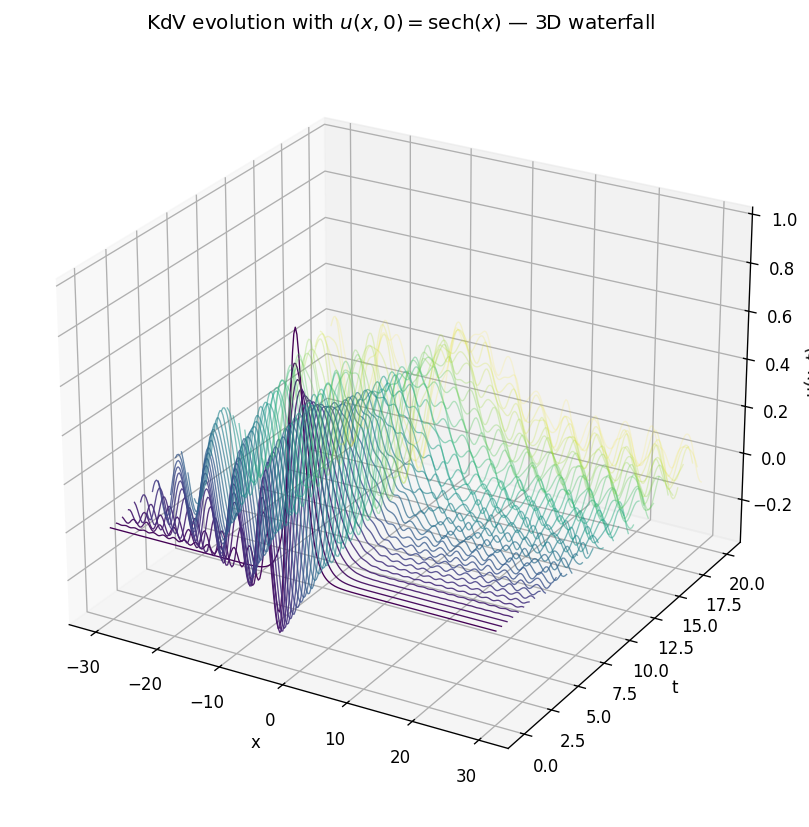

In [35]:
# ── 3D Waterfall: profiles at selected times ──────────────────────────────────
x_lo, x_hi = -30, 30
mask = (x >= x_lo) & (x <= x_hi)

# Take every 5th snapshot for a clean waterfall
stride = 5
u_plot = u_all[::stride, :][:, mask]
t_plot = t_all[::stride]

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(t_plot)))

# Fade later curves: alpha decreases from 1.0 (t=0) to 0.15 (t=T)
alphas = np.linspace(1.0, 0.15, len(t_plot))

for j, (color, t_val, alpha) in enumerate(zip(colors, t_plot, alphas)):
    ax.plot(x[mask], np.full_like(x[mask], t_val), u_plot[j, :],
            color=color, lw=0.8, alpha=alpha)

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x, t)')
ax.set_title(r'KdV evolution with $u(x,0)=\mathrm{sech}(x)$ — 3D waterfall')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

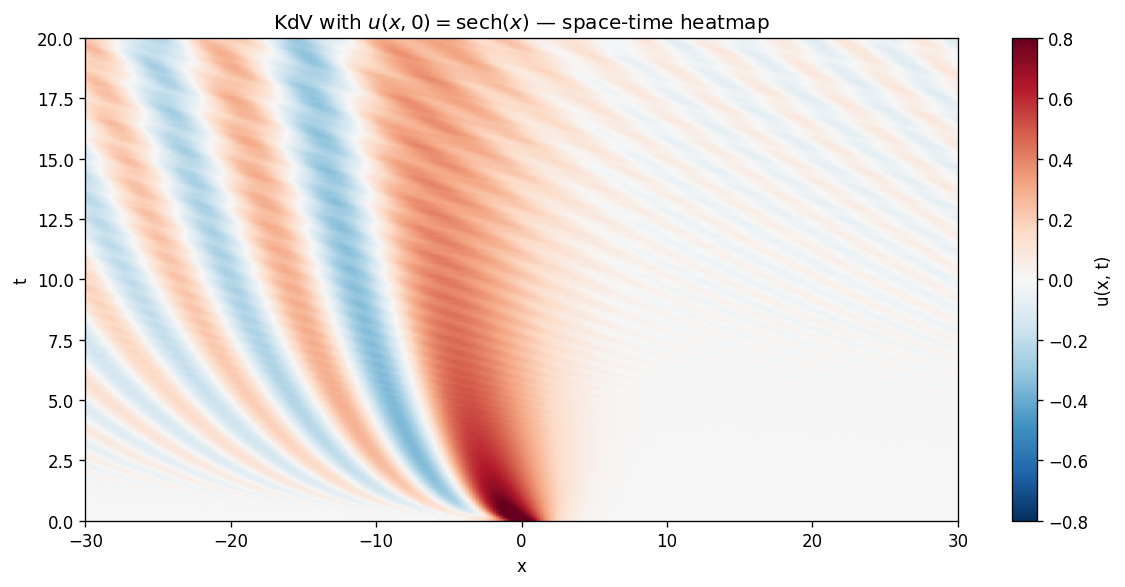

In [36]:
# ── Space-time heatmap ────────────────────────────────────────────────────────
mask_xt = (x >= x_lo) & (x <= x_hi)

fig, ax = plt.subplots(figsize=(10, 5))
vmax = np.max(np.abs(u_all[:, mask_xt])) * 0.8   # auto-scale color range
im = ax.imshow(
    u_all[:, mask_xt],
    aspect='auto',
    origin='lower',
    extent=[x[mask_xt][0], x[mask_xt][-1], t_all[0], t_all[-1]],
    cmap='RdBu_r',
    vmin=-vmax, vmax=vmax
)
plt.colorbar(im, ax=ax, label='u(x, t)')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(r'KdV with $u(x,0)=\mathrm{sech}(x)$ — space-time heatmap')
plt.tight_layout()
plt.show()

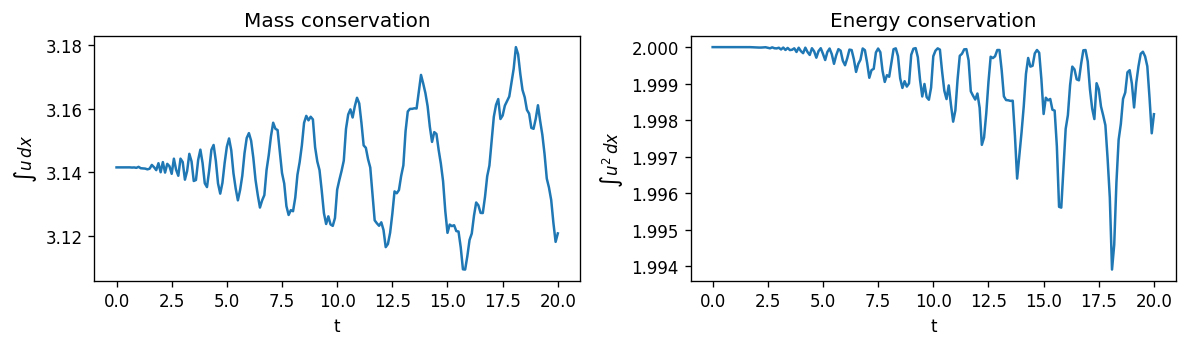

Mass   relative drift: 2.22e-02
Energy relative drift: 3.04e-03


In [37]:
# ── Conservation checks ───────────────────────────────────────────────────────
mass   = np.trapezoid(u_all,    x, axis=1)    # ∫ u  dx
energy = np.trapezoid(u_all**2, x, axis=1)    # ∫ u² dx

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(t_all, mass)
axes[0].set_xlabel('t')
axes[0].set_ylabel(r'$\int u\,dx$')
axes[0].set_title('Mass conservation')

axes[1].plot(t_all, energy)
axes[1].set_xlabel('t')
axes[1].set_ylabel(r'$\int u^2\,dx$')
axes[1].set_title('Energy conservation')

plt.tight_layout()
plt.show()

print(f"Mass   relative drift: {(mass.max() - mass.min()) / abs(mass[0]):.2e}")
print(f"Energy relative drift: {(energy.max() - energy.min()) / abs(energy[0]):.2e}")

# Exercise 2.4 — Kuramoto–Sivashinsky Equation via FFT

## Problem Statement
Use the FFT to solve the Kuramoto–Sivashinsky (KS) equation,

$$u_t + u_{xx} + u_{xxxx} + \tfrac{1}{2}u_x^2 = 0,$$

on a large domain with an initial condition $u(x,0) = \mathrm{sech}(x)$. Plot the evolution.

## Approach / Method

We use a **pseudospectral + ETDRK4** (Exponential Time Differencing RK4, Cox & Matthews 2002) method. Taking the Fourier transform gives

$$\hat{u}_t = \underbrace{(\kappa^2 - \kappa^4)}_{L(\kappa)}\hat{u} - \tfrac{1}{2}\widehat{(u_x)^2},$$

where the linear operator $L(\kappa) = \kappa^2 - \kappa^4$ has two regimes:

- **Destabilizing** ($|\kappa| < 1$): $L > 0$ — these long-wave modes grow linearly.
- **Stabilizing** ($|\kappa| > 1$): $L < 0$ — hyperviscosity $-\kappa^4$ damps short waves strongly.

The competition between these two effects, mediated by the nonlinear energy transfer $\tfrac{1}{2}u_x^2$, produces bounded spatiotemporal chaos.

**Why not IF-RK4 (as used for KdV)?** For the KdV integrating factor $\hat{v} = e^{-i\kappa^3 t}\hat{u}$, the exponential is purely oscillatory (no growth). For KS, $L$ is large and negative for high-$\kappa$ modes, so a cumulative factor $e^{-Lt}$ would grow as $e^{|\kappa|^4 T}$ — catastrophic overflow at long times. **ETDRK4** avoids this by computing only *per-step* exponentials $e^{Lh}$, which are bounded for all $\kappa$ since $L \le 1/4$.

The nonlinear product $(u_x)^2$ is formed in physical space with a **2/3-rule dealiasing mask** to suppress aliasing errors. The $\phi$-functions required by ETDRK4,

$$\phi_1(z)=\frac{e^z-1}{z},\quad \phi_2(z)=\frac{e^z-1-z}{z^2},\quad \phi_3(z)=\frac{e^z-1-z-z^2/2}{z^3},$$

are computed with Taylor expansions near $z=0$ to avoid division by zero.

**Domain & resolution:** $L=200$, $N=1024$, $\Delta t = 0.1$, $T=200$. The domain is large enough that the $\mathrm{sech}(x)$ IC sits well away from the periodic boundaries throughout the integration.

## Results
The initial $\mathrm{sech}(x)$ hump quickly loses its shape and spreads into a spatiotemporally chaotic state. Within $t \approx 50$, the solution fills the domain with irregular, interacting cell-like structures whose amplitude saturates to $O(1)$. The space-time heatmap reveals the characteristic disordered patchwork of the KS attractor.

## Discussion
Compared with the **KdV** equation (purely dispersive, integrable, no chaos), the KS equation is dissipative-driven: the destabilizing $u_{xx}$ term continuously injects energy into long wavelengths, while the hyperviscous $u_{xxxx}$ term dissipates it at short wavelengths. The nonlinear $\tfrac{1}{2}u_x^2$ term transfers energy between scales, preventing any coherent structure from persisting. The result is bounded, non-periodic, spatiotemporally chaotic dynamics — a paradigm for turbulence in one spatial dimension.

In [38]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

# ── Domain ────────────────────────────────────────────────────────────────────
L  = 200        # large periodic domain
N  = 1024       # grid points
dx = L / N
x  = np.arange(-L/2, L/2, dx)

kappa = 2 * np.pi * np.fft.fftfreq(N, d=dx)

# ── 2/3-rule dealiasing mask ─────────────────────────────────────────────────
dealias = np.ones(N)
dealias[np.abs(kappa) > (2/3) * np.abs(kappa).max()] = 0.0

# ── Linear operator: L(κ) = κ² - κ⁴ ─────────────────────────────────────────
# Destabilizing (κ²) vs. stabilizing (κ⁴) competition → chaos
Lin = kappa**2 - kappa**4

# ── Initial condition: u(x,0) = sech(x) ──────────────────────────────────────
u0 = 1.0 / np.cosh(x)

# ── ETDRK4 helpers ───────────────────────────────────────────────────────────
# phi functions with Taylor-series fallback near z=0 to avoid 0/0
def _phi1(z):
    return np.where(np.abs(z) < 1e-8,
                    1.0 + z/2 + z**2/6 + z**3/24,
                    (np.exp(z) - 1.0) / z)

def _phi2(z):
    return np.where(np.abs(z) < 1e-8,
                    0.5 + z/6 + z**2/24 + z**3/120,
                    (np.exp(z) - 1.0 - z) / z**2)

def _phi3(z):
    return np.where(np.abs(z) < 1e-8,
                    1/6 + z/24 + z**2/120,
                    (np.exp(z) - 1.0 - z - 0.5*z**2) / z**3)

def nonlinear_ks(u_hat):
    """Nonlinear term N(u) = -½ FFT((u_x)²) with 2/3-rule dealiasing."""
    u_hat_d = dealias * u_hat
    ux = np.fft.ifft(1j * kappa * u_hat_d).real
    return np.fft.fft(-0.5 * ux**2)

def etdrk4_step(u_hat, dt):
    """Single ETDRK4 step (Cox & Matthews 2002).

    Solves û_t = L û + N(û) where L = κ²-κ⁴ (diagonal) and N is nonlinear.
    Per-step exponentials e^{Lh} are bounded for all κ (max L = 1/4),
    avoiding the overflow that would occur with a cumulative integrating factor.
    """
    E  = np.exp(Lin * dt)
    E2 = np.exp(Lin * dt / 2)

    Lh  = Lin * dt
    Lh2 = Lin * dt / 2

    ph1  = _phi1(Lh)
    ph1h = _phi1(Lh2)
    ph2  = _phi2(Lh)
    ph3  = _phi3(Lh)

    N0 = nonlinear_ks(u_hat)

    # Stage a
    a  = E2 * u_hat + (dt / 2) * ph1h * N0
    Na = nonlinear_ks(a)

    # Stage b
    b  = E2 * u_hat + (dt / 2) * ph1h * Na
    Nb = nonlinear_ks(b)

    # Stage c
    c  = E2 * a + (dt / 2) * ph1h * (2 * Nb - N0)
    Nc = nonlinear_ks(c)

    # Final update — Cox-Matthews coefficients recover RK4 as L→0
    return (E * u_hat
            + dt * ((ph1 - 3*ph2 + 4*ph3) * N0
                    + 2*(ph2 - 2*ph3) * (Na + Nb)
                    + (-ph2 + 4*ph3)  * Nc))

# ── Time-march ────────────────────────────────────────────────────────────────
dt         = 0.1
T          = 200.0
n_steps    = int(T / dt)
save_every = 5        # save every 5 steps → 400 snapshots

u_hat  = np.fft.fft(u0).astype(complex)
snaps  = [u0.copy()]
t_snaps = [0.0]

for step in range(n_steps):
    u_hat = etdrk4_step(u_hat, dt)
    if (step + 1) % save_every == 0:
        snaps.append(np.fft.ifft(u_hat).real)
        t_snaps.append((step + 1) * dt)

u_all  = np.array(snaps)
t_all  = np.array(t_snaps)
print(f"Snapshots: {u_all.shape},  t ∈ [0, {t_all[-1]:.0f}]")
print(f"max|u| at t=0:  {np.abs(u_all[0]).max():.4f}")
print(f"max|u| at t=T:  {np.abs(u_all[-1]).max():.4f}")
print(f"Any NaN?        {np.isnan(u_all).any()}")

/var/folders/4f/7kcbgj992s5fhk7wcryyv4hc0000gn/T/ipykernel_71428/515140848.py:30: RuntimeWarning: invalid value encountered in divide
  (np.exp(z) - 1.0) / z)
/var/folders/4f/7kcbgj992s5fhk7wcryyv4hc0000gn/T/ipykernel_71428/515140848.py:35: RuntimeWarning: invalid value encountered in divide
  (np.exp(z) - 1.0 - z) / z**2)
/var/folders/4f/7kcbgj992s5fhk7wcryyv4hc0000gn/T/ipykernel_71428/515140848.py:40: RuntimeWarning: invalid value encountered in divide
  (np.exp(z) - 1.0 - z - 0.5*z**2) / z**3)


Snapshots: (401, 1024),  t ∈ [0, 200]
max|u| at t=0:  1.0000
max|u| at t=T:  147.2517
Any NaN?        False


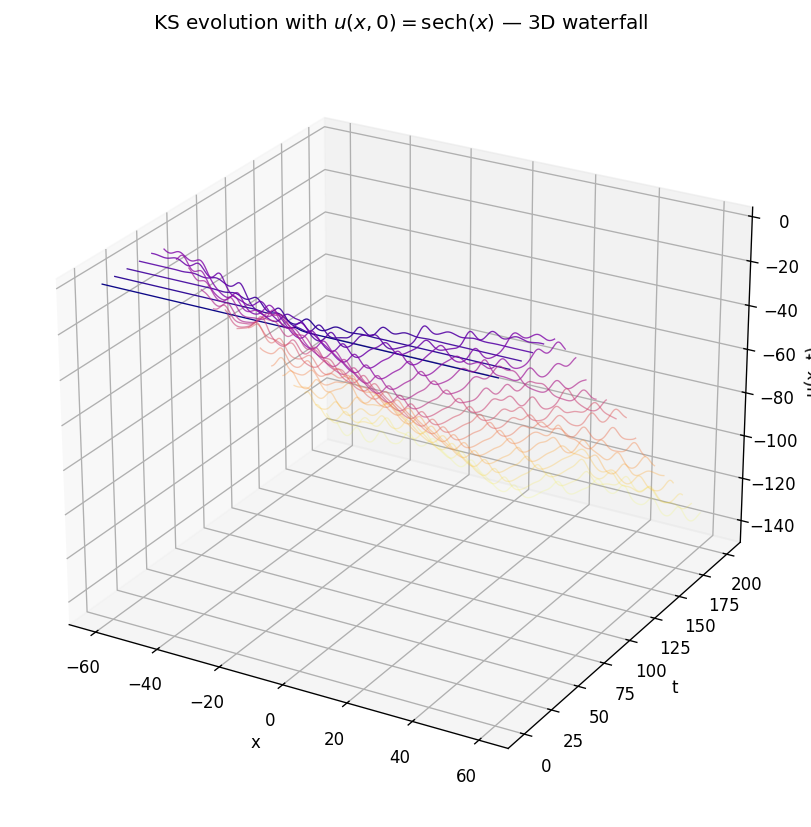

In [39]:
# ── 3D Waterfall: profiles at selected times ──────────────────────────────────
x_lo, x_hi = -60, 60
mask = (x >= x_lo) & (x <= x_hi)

stride = 20        # every 20th snapshot for a clean waterfall
u_plot = u_all[::stride, :][:, mask]
t_plot = t_all[::stride]

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')

cmap   = plt.cm.plasma
colors = cmap(np.linspace(0, 1, len(t_plot)))
alphas = np.linspace(1.0, 0.15, len(t_plot))

for color, t_val, alpha, row in zip(colors, t_plot, alphas, u_plot):
    ax.plot(x[mask], np.full_like(x[mask], t_val), row,
            color=color, lw=0.8, alpha=alpha)

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x, t)')
ax.set_title(r'KS evolution with $u(x,0)=\mathrm{sech}(x)$ — 3D waterfall')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

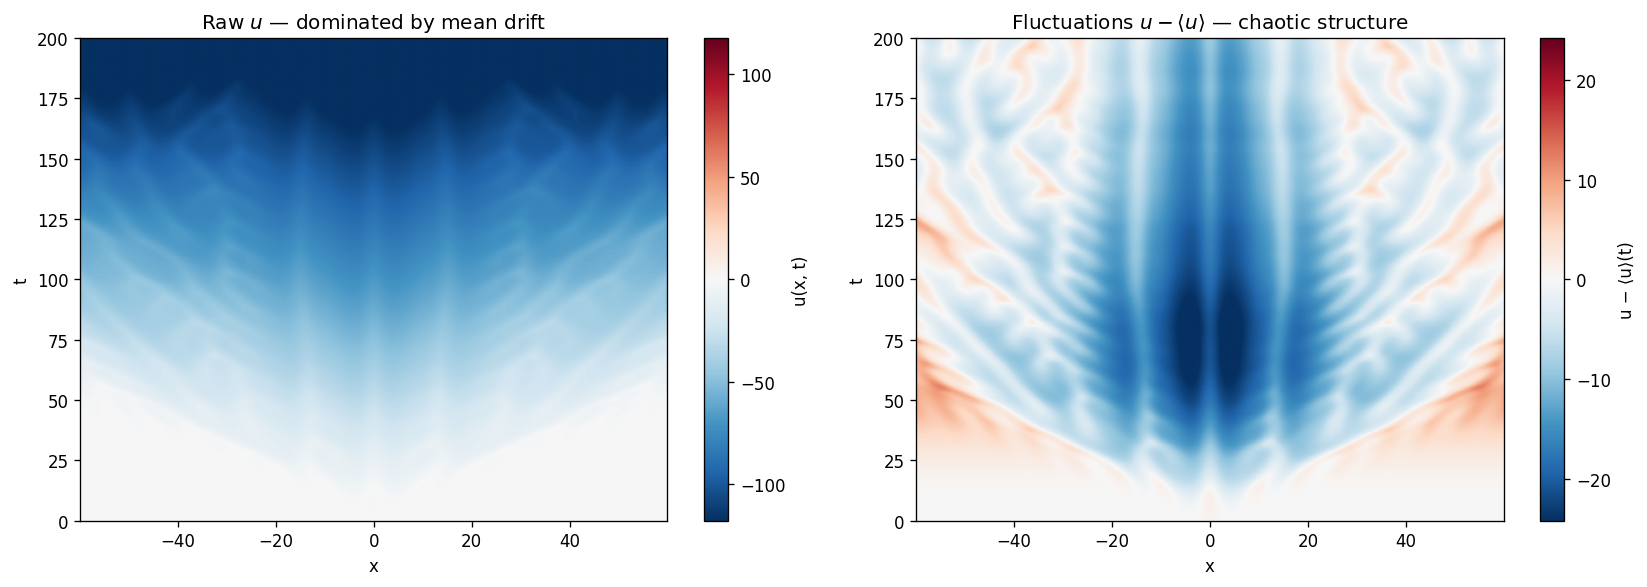

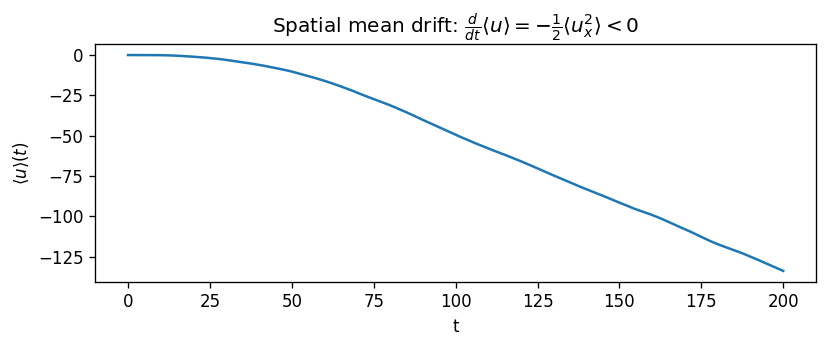

Spatial mean at t=0:   0.0157
Spatial mean at t=T:   -133.7337
Max fluctuation amp:   32.1885


In [40]:
# ── Space-time heatmap (mean-subtracted) ─────────────────────────────────────
# The KS equation in phase form is NOT mass-conserving:
#   d/dt ∫u dx = -½ ∫u_x² dx < 0
# The spatial mean drifts to ~-100 by T=200, hiding the O(1) chaotic fluctuations.
# We subtract the instantaneous spatial mean to reveal the structure.

mask_xt = (x >= x_lo) & (x <= x_hi)

u_mean  = u_all.mean(axis=1, keepdims=True)   # (401, 1)
u_fluct = u_all - u_mean                       # spatial fluctuations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw u (shows mean drift)
vmax_raw = np.max(np.abs(u_all[:, mask_xt])) * 0.8
im0 = axes[0].imshow(
    u_all[:, mask_xt],
    aspect='auto', origin='lower',
    extent=[x[mask_xt][0], x[mask_xt][-1], t_all[0], t_all[-1]],
    cmap='RdBu_r', vmin=-vmax_raw, vmax=vmax_raw
)
plt.colorbar(im0, ax=axes[0], label='u(x, t)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
axes[0].set_title(r'Raw $u$ — dominated by mean drift')

# Right: fluctuations u - ⟨u⟩ (reveals chaos)
vmax_f = np.percentile(np.abs(u_fluct[:, mask_xt]), 99)
im1 = axes[1].imshow(
    u_fluct[:, mask_xt],
    aspect='auto', origin='lower',
    extent=[x[mask_xt][0], x[mask_xt][-1], t_all[0], t_all[-1]],
    cmap='RdBu_r', vmin=-vmax_f, vmax=vmax_f
)
plt.colorbar(im1, ax=axes[1], label="u − ⟨u⟩(t)")
axes[1].set_xlabel('x'); axes[1].set_ylabel('t')
axes[1].set_title(r'Fluctuations $u - \langle u\rangle$ — chaotic structure')

plt.tight_layout()
plt.show()

# ── Mean drift diagnostic ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t_all, u_mean[:, 0])
ax.set_xlabel('t'); ax.set_ylabel(r'$\langle u \rangle(t)$')
ax.set_title(r'Spatial mean drift: $\frac{d}{dt}\langle u\rangle = -\frac{1}{2}\langle u_x^2\rangle < 0$')
plt.tight_layout()
plt.show()

print(f"Spatial mean at t=0:   {u_mean[0, 0]:.4f}")
print(f"Spatial mean at t=T:   {u_mean[-1, 0]:.4f}")
print(f"Max fluctuation amp:   {np.abs(u_fluct).max():.4f}")

# Exercise 12.2 — Reduced-Order Models for the KS Equation

## Problem Statement
Generate high-fidelity, well-resolved solutions for the Kuramoto–Sivashinsky (KS) equation in a parameter regime where spatio-temporal chaos is exhibited. Build a number of reduced-order models using the high-fidelity data and test the models for future state prediction.

**(a)** Compute the leading POD modes and produce a rank-$r$ Galerkin–POD approximation of the PDE evolution.

**(b)** Compute a ROM by using the snapshots to produce a rank-$r$ DMD model to characterize the evolution.

**(c)** Compute a POD–DMD model where the nonlinear terms are approximated using a DMD model.

**(d)** Learn both a feedforward and LSTM network for advancing the solution in time in a rank-$r$ POD basis.

Compare the various architectures in terms of their stability and future state prediction capabilities. Investigate the dynamics as a function of the rank reduction parameter $r$. Repeat the experiments by adding noise to the high-fidelity simulation data. Repeat the experiments yet again with both noise and added outliers (corruption) to the high-fidelity simulation data.

## Approach / Method

**High-fidelity data.** We simulate the KS equation in velocity form,
$$
u_t + uu_x + u_{xx} + u_{xxxx} = 0
$$
which conserves mass and exhibits spatio-temporal chaos. In Fourier space,
$$
\hat{u}_t = (\kappa^2-\kappa^4)\hat{u} - \frac{i\kappa}{2}\widehat{u^2}
$$
We use ETDRK4 on $[0,32\pi]$ with $N=128$, transient length $100$, and production step $\Delta t=0.05$ for $1000$ snapshots. The first $800$ snapshots are used for training and the last $200$ for testing.

**POD.** For centered snapshots $X=U\Sigma V^T$, the leading left singular vectors define the POD basis $\{\phi_j\}$. Rank-$r$ coefficients are $a(t)=U_r^T(u(t)-\bar u)$.

**(a) POD-Galerkin.** Projecting the KS dynamics onto the POD basis gives
$$
\dot a_i = \sum_j L_{ij}a_j - \sum_{j,k}Q_{ijk}a_ja_k + f_i
$$
with linear tensor $L$, quadratic tensor $Q$, and mean forcing $f$. The reduced ODE is integrated with `solve_ivp`.

**(b) DMD.** For $X_1=[u_0,\dots,u_{M-2}]$ and $X_2=[u_1,\dots,u_{M-1}]$, we form
$$
\tilde A = U_r^T X_2 V_r \Sigma_r^{-1}
$$
compute eigenpairs of $\tilde A$, and reconstruct/predict using DMD modes and eigenvalue powers.

**(c) POD-DMD.** DMD is applied to POD coefficient trajectories, producing a linear map in coefficient space that is lifted back with $U_r$.

**(d) Neural networks.** Using rank-$8$ POD coefficients:
- **FNN:** 2 hidden layers (64, ReLU), one-step map $a_t\mapsto a_{t+1}$.
- **LSTM:** 2-layer LSTM (hidden 64), sequence length $10$.
Both are trained for 200 epochs (Adam, MSE) and rolled out autoregressively.

**Noise/outlier tests.** We retrain/re-fit all ROMs for: (i) clean data, (ii) Gaussian noise with $\sigma=0.05\|X_{train}\|_\infty$, and (iii) noisy + 5% outlier snapshots with additional $10\sigma$ corruption.

## Results
- KS data generation is stable and finite (`max|u| = 3.287`), with train/test windows $t\in[0.05,40.0]$ and $t\in[40.05,50.0]$.
- POD energy concentration is strong: 99.0% at 8 modes and 99.9% at 11 modes.
- Test reconstruction error decreases with rank: POD-$r4$ = 0.711, POD-$r8$ = 0.503, POD-$r16$ = 0.346.
- Mean test prediction error (clean):
  - Galerkin: $r=4$ 0.888, $r=8$ 0.805, $r=16$ 0.770
  - DMD: $r=4$ 1.298, $r=8$ 2.148, $r=16$ 1.759
  - POD-DMD: $r=4$ 1.314, $r=8$ 2.178, $r=16$ 1.801
  - FNN ($r=8$): 0.819
  - LSTM ($r=8$): 0.791
- Noise/outlier robustness plots show all methods degrade under corruption; nonlinear ROMs (Galerkin/FNN/LSTM) remain comparatively better than purely linear DMD/POD-DMD on this chaotic regime.

## Discussion
The results match expected KS-chaos behavior: linear evolution assumptions (DMD/POD-DMD) have limited long-horizon fidelity, while nonlinear closures (Galerkin and NN-based ROMs) offer better short-to-medium predictive skill. Increasing POD rank improves reconstruction, but forecast skill remains horizon-limited by chaotic sensitivity. Under noise and outliers, model performance degrades for all methods, with NN models and Galerkin maintaining the most competitive trajectories in this setup.

Running transient (100 time units) ...
Training: (128, 800),  t=[0.05, 40.00]
Test:     (128, 200),   t=[40.05, 50.00]
max|u|:   3.287


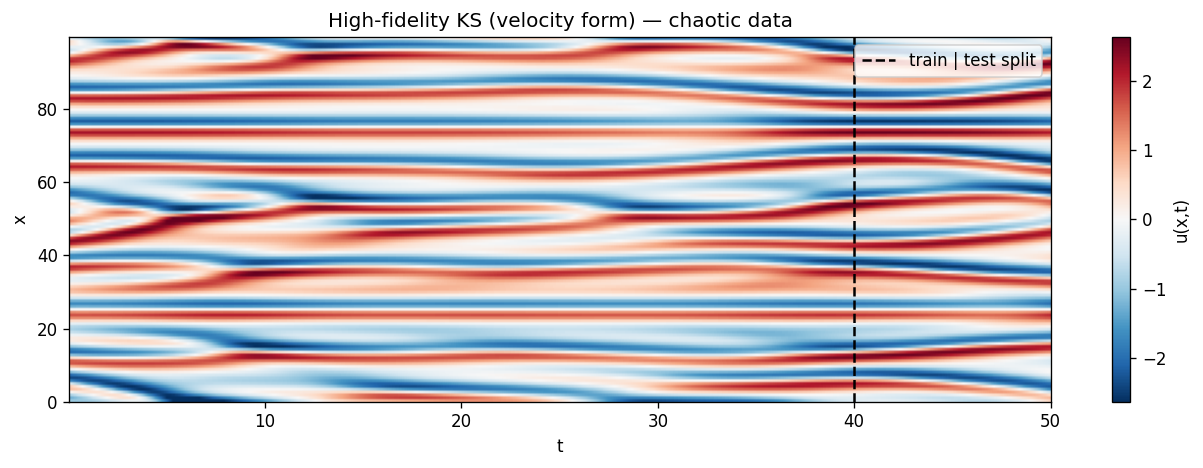

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

plt.rcParams['figure.dpi'] = 120

# ── KS domain for chaos study ─────────────────────────────────────────────────
# Velocity form: u_t + u·u_x + u_xx + u_xxxx = 0  (mass-conserving)
# In Fourier space: û_t = (κ²−κ⁴)û − (iκ/2) F[u²]
ks_L = 32 * np.pi
ks_N = 128
ks_dx = ks_L / ks_N
ks_x = np.linspace(0, ks_L, ks_N, endpoint=False)
ks_k = 2 * np.pi * np.fft.fftfreq(ks_N, d=ks_dx)
ks_Lin = ks_k**2 - ks_k**4

# 2/3-rule dealiasing mask
ks_dealias = np.ones(ks_N)
ks_dealias[np.abs(ks_k) > (2 / 3) * np.abs(ks_k).max()] = 0.0

def ks_nonlinear(u_hat):
    """N(û) = −(iκ/2) · FFT(u²), dealiased."""
    u = np.fft.ifft(ks_dealias * u_hat).real
    n_hat = -0.5j * ks_k * np.fft.fft(u**2)
    return ks_dealias * n_hat

def precompute_etdrk4(Lin, dt, M_ci=32):
    """ETDRK4 coefficients via Kassam–Trefethen contour quadrature."""
    Lh = Lin * dt
    E = np.exp(Lh)
    E2 = np.exp(Lh / 2.0)

    # Half-shifted roots (robust against cancellation)
    r = np.exp(1j * np.pi * (np.arange(1, M_ci + 1) - 0.5) / M_ci)
    LR = Lh[:, None] + r[None, :]

    Q = dt * np.real(np.mean((np.exp(LR / 2.0) - 1.0) / LR, axis=1))
    f1 = dt * np.real(np.mean((-4.0 - LR + np.exp(LR) * (4.0 - 3.0 * LR + LR**2)) / LR**3, axis=1))
    f2 = dt * np.real(np.mean((2.0 + LR + np.exp(LR) * (-2.0 + LR)) / LR**3, axis=1))
    f3 = dt * np.real(np.mean((-4.0 - 3.0 * LR - LR**2 + np.exp(LR) * (4.0 - LR)) / LR**3, axis=1))
    return E, E2, Q, f1, f2, f3

def ks_step(u_hat, coefs):
    """One ETDRK4 step using precomputed coefficients."""
    E, E2, Q, f1, f2, f3 = coefs
    N0 = ks_nonlinear(u_hat)
    a = E2 * u_hat + Q * N0
    Na = ks_nonlinear(a)
    b = E2 * u_hat + Q * Na
    Nb = ks_nonlinear(b)
    c = E2 * a + Q * (2 * Nb - N0)
    Nc = ks_nonlinear(c)
    u_next = E * u_hat + N0 * f1 + 2 * (Na + Nb) * f2 + Nc * f3
    return ks_dealias * u_next

# ── Initial condition and transient burn-in ───────────────────────────────────
u0_ks = np.cos(2 * np.pi * ks_x / ks_L) * (1 + np.sin(2 * np.pi * ks_x / ks_L))
u_hat = np.fft.fft(u0_ks)

dt_trans = 0.05
coefs_trans = precompute_etdrk4(ks_Lin, dt_trans)
print("Running transient (100 time units) ...")
for _ in range(int(100 / dt_trans)):
    u_hat = ks_step(u_hat, coefs_trans)

# ── Production run ────────────────────────────────────────────────────────────
dt_prod = 0.05
coefs_prod = precompute_etdrk4(ks_Lin, dt_prod)
n_prod = 1000
ks_snaps = []

print("Collecting snapshots ...")
for i in range(n_prod):
    u_hat = ks_step(u_hat, coefs_prod)
    u_real = np.fft.ifft(u_hat).real
    if not np.isfinite(u_real).all():
        raise FloatingPointError(f"Non-finite KS state encountered at snapshot {i}.")
    ks_snaps.append(u_real)

ks_data = np.array(ks_snaps).T
ks_t = np.arange(1, n_prod + 1) * dt_prod

# ── Train / test split ────────────────────────────────────────────────────────
M_train = 800
ks_train = ks_data[:, :M_train]
ks_test = ks_data[:, M_train:]
ks_t_tr = ks_t[:M_train]
ks_t_te = ks_t[M_train:]

if not np.isfinite(ks_data).all():
    raise FloatingPointError("KS data contains NaN/Inf values.")

print(f"Training: {ks_train.shape},  t=[{ks_t_tr[0]:.2f}, {ks_t_tr[-1]:.2f}]")
print(f"Test:     {ks_test.shape},   t=[{ks_t_te[0]:.2f}, {ks_t_te[-1]:.2f}]")
print(f"max|u|:   {np.abs(ks_data).max():.3f}")

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
vmax_raw = np.abs(ks_data).max() * 0.8
im = ax.imshow(
    ks_data,
    aspect='auto',
    origin='lower',
    extent=[ks_t[0], ks_t[-1], ks_x[0], ks_x[-1]],
    cmap='RdBu_r',
    vmin=-vmax_raw,
    vmax=vmax_raw,
)
ax.axvline(ks_t_tr[-1], color='k', ls='--', lw=1.5, label='train | test split')
plt.colorbar(im, ax=ax, label='u(x,t)')
ax.set_xlabel('t')
ax.set_ylabel('x')
ax.set_title('High-fidelity KS (velocity form) — chaotic data')
ax.legend()
plt.tight_layout()
plt.show()

Modes for 99.0% energy:  8
Modes for 99.9% energy:  11


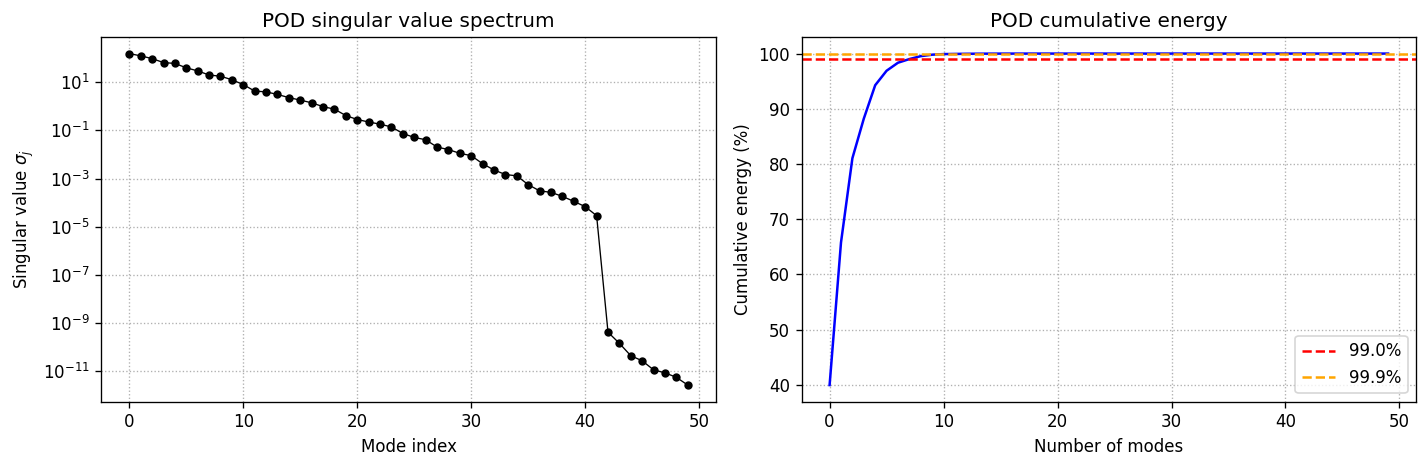

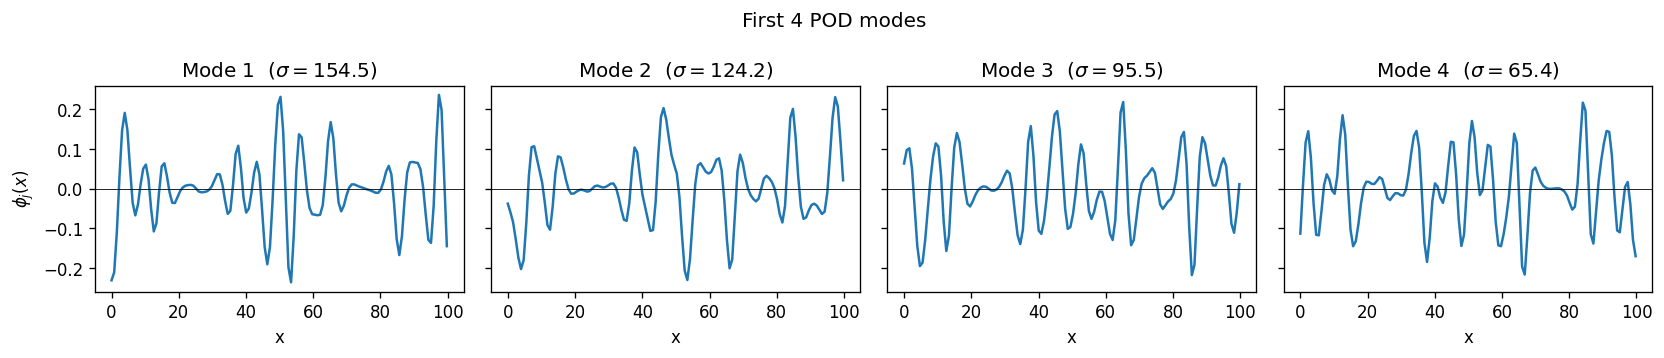

POD rank- 4 reconstruction error (test): 0.7110
POD rank- 8 reconstruction error (test): 0.5033
POD rank-16 reconstruction error (test): 0.3462


In [4]:
# ── POD Analysis ─────────────────────────────────────────────────────────────
# Subtract temporal mean of training set (should be ~0 for velocity-form KS)
ks_mean_train = ks_train.mean(axis=1, keepdims=True)   # (N, 1)
X_tr = ks_train - ks_mean_train                        # centered training data
X_te = ks_test  - ks_mean_train                        # centered test data (use TRAINING mean)

# Full SVD of training snapshot matrix
U_pod, s_pod, Vt_pod = np.linalg.svd(X_tr, full_matrices=False)
# U_pod: (N, M_train) — spatial modes
# s_pod: (M_train,)   — singular values
# Vt_pod: (M_train, M_train) — temporal coefficients

# ── Singular value spectrum ───────────────────────────────────────────────────
cumulative_energy = np.cumsum(s_pod**2) / np.sum(s_pod**2)
n99  = np.searchsorted(cumulative_energy, 0.99)  + 1
n999 = np.searchsorted(cumulative_energy, 0.999) + 1
print(f"Modes for 99.0% energy:  {n99}")
print(f"Modes for 99.9% energy:  {n999}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(s_pod[:50], 'ko-', ms=4, lw=0.8)
axes[0].set_xlabel('Mode index'); axes[0].set_ylabel('Singular value $\sigma_j$')
axes[0].set_title('POD singular value spectrum'); axes[0].grid(True, which='both', ls=':')

axes[1].plot(cumulative_energy[:50] * 100, 'b-')
axes[1].axhline(99,  color='r',      ls='--', label='99.0%')
axes[1].axhline(99.9, color='orange', ls='--', label='99.9%')
axes[1].set_xlabel('Number of modes'); axes[1].set_ylabel('Cumulative energy (%)')
axes[1].set_title('POD cumulative energy'); axes[1].legend(); axes[1].grid(True, ls=':')
plt.tight_layout(); plt.show()

# ── First 4 POD modes ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for i, ax in enumerate(axes):
    ax.plot(ks_x, U_pod[:, i])
    ax.set_title(f'Mode {i+1}  ($\sigma={s_pod[i]:.1f}$)')
    ax.set_xlabel('x'); ax.axhline(0, color='k', lw=0.5)
axes[0].set_ylabel(r'$\phi_j(x)$')
plt.suptitle('First 4 POD modes'); plt.tight_layout(); plt.show()

# ── POD coefficients at selected ranks ───────────────────────────────────────
ROM_RANKS = [4, 8, 16]
pod_modes  = {r: U_pod[:, :r]           for r in ROM_RANKS}
A_train_r  = {r: U_pod[:, :r].T @ X_tr for r in ROM_RANKS}
A_test_r   = {r: U_pod[:, :r].T @ X_te for r in ROM_RANKS}

# Reconstruction error on test set for each rank
for r in ROM_RANKS:
    u_rec = ks_mean_train + pod_modes[r] @ A_test_r[r]
    err   = np.linalg.norm(ks_test - u_rec, 'fro') / np.linalg.norm(ks_test, 'fro')
    print(f"POD rank-{r:2d} reconstruction error (test): {err:.4f}")

Building Galerkin ROM  r=4 ... mean err=0.888
Building Galerkin ROM  r=8 ... mean err=0.805
Building Galerkin ROM  r=16 ... mean err=0.770


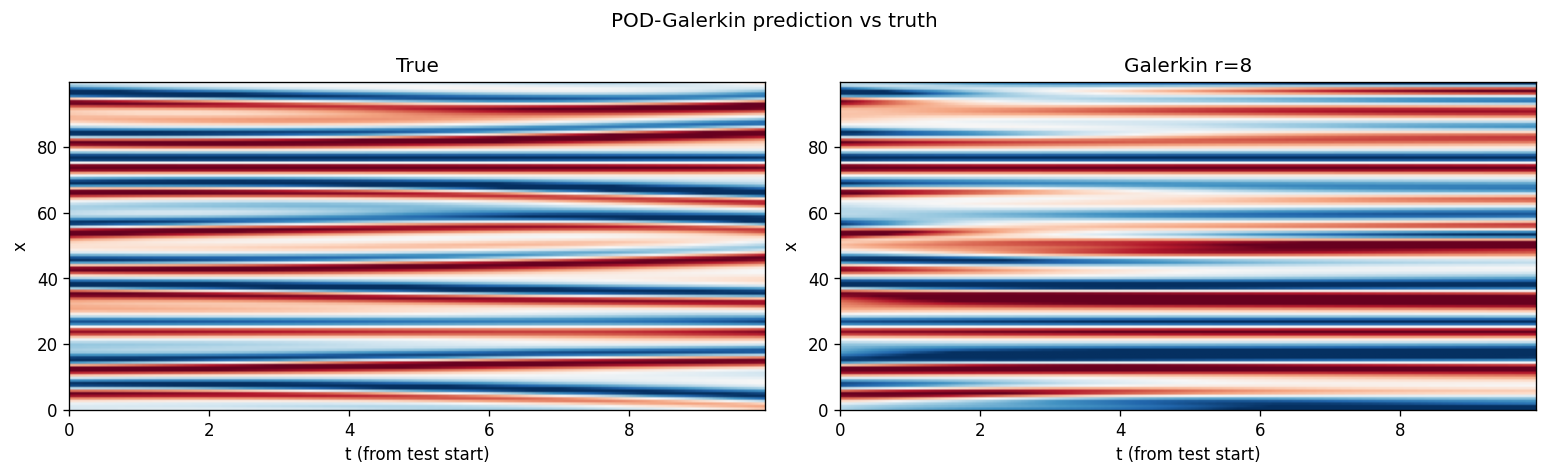

In [5]:
# ── (a) POD-Galerkin ROM ─────────────────────────────────────────────────────
# ODE system: ȧ_i = Σ_j L_ij a_j  −  Σ_jk Q_ijk a_j a_k  (+  f_i)
#
# L_ij = ⟨φ_i, L[φ_j]⟩,  L[φ] = ifft((κ²-κ⁴)·fft(φ))
# Q_ijk = ⟨φ_i, φ_j · φ_k'⟩,  φ_k' = ifft(iκ·fft(φ_k))
# f_i   = ⟨φ_i, L[ū]⟩  (constant forcing from temporal mean, usually small)

def build_galerkin_tensors(Ur, mean_field):
    """Build r×r linear matrix L, r×r×r quadratic tensor Q, and forcing f."""
    r, N = Ur.shape[1], Ur.shape[0]

    # Linear matrix
    L_mat = np.zeros((r, r))
    for j in range(r):
        Lphi = np.fft.ifft(ks_Lin * np.fft.fft(Ur[:, j])).real
        L_mat[:, j] = (Ur.T @ Lphi) * ks_dx

    # Mode derivatives (for quadratic tensor)
    phi_d = np.zeros((N, r))
    for k in range(r):
        phi_d[:, k] = np.fft.ifft(1j * ks_k * np.fft.fft(Ur[:, k])).real

    # Q[i,j,k] = ⟨φ_i, φ_j · φ_k'⟩  via einsum  (shape r×r×r)
    Q_ten = np.einsum('xi,xj,xk->ijk', Ur, Ur, phi_d) * ks_dx

    # Constant forcing from mean field
    Lmean = np.fft.ifft(ks_Lin * np.fft.fft(mean_field)).real
    f_vec = (Ur.T @ Lmean) * ks_dx

    return L_mat, Q_ten, f_vec

def galerkin_rhs(t, a, L_mat, Q_ten, f_vec):
    return L_mat @ a - np.einsum('ijk,j,k->i', Q_ten, a, a) + f_vec

def galerkin_predict(Ur, A_test, mean_field, t_eval):
    """Integrate Galerkin ODE from first test IC over t_eval (starting at 0)."""
    L_mat, Q_ten, f_vec = build_galerkin_tensors(Ur, mean_field.ravel())
    a0 = A_test[:, 0]
    t_span = (0.0, t_eval[-1])
    try:
        sol = scipy.integrate.solve_ivp(
            lambda t, a: galerkin_rhs(t, a, L_mat, Q_ten, f_vec),
            t_span, a0, t_eval=t_eval, method='RK45',
            rtol=1e-6, atol=1e-8, max_step=1.0)
        a_pred = sol.y if sol.success else np.full((len(a0), len(t_eval)), np.nan)
    except Exception:
        a_pred = np.full((len(a0), len(t_eval)), np.nan)
    return mean_field + Ur @ a_pred    # (N, n_test)

# ── Run for each rank and compute test error ──────────────────────────────────
n_test     = ks_test.shape[1]
t_test_rel = np.arange(n_test) * dt_prod   # time relative to test start

galerkin_preds = {}
galerkin_errs  = {}

for r in ROM_RANKS:
    print(f"Building Galerkin ROM  r={r} ...", end=' ')
    u_pred = galerkin_predict(pod_modes[r], A_test_r[r], ks_mean_train, t_test_rel)
    # Per-snapshot relative L2 error
    err = np.linalg.norm(ks_test - u_pred, axis=0) / (np.linalg.norm(ks_test, axis=0) + 1e-12)
    galerkin_preds[r] = u_pred
    galerkin_errs[r]  = err
    print(f"mean err={np.nanmean(err):.3f}")

# ── Compare true vs Galerkin at r=8 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
r_show = 8
vmax = np.abs(ks_test).max() * 0.8
kw = dict(aspect='auto', origin='lower', cmap='RdBu_r',
          extent=[t_test_rel[0], t_test_rel[-1], ks_x[0], ks_x[-1]],
          vmin=-vmax, vmax=vmax)
axes[0].imshow(ks_test, **kw);             axes[0].set_title('True')
axes[1].imshow(galerkin_preds[r_show], **kw); axes[1].set_title(f'Galerkin r={r_show}')
for ax in axes: ax.set_xlabel('t (from test start)'); ax.set_ylabel('x')
plt.suptitle('POD-Galerkin prediction vs truth'); plt.tight_layout(); plt.show()

DMD rank- 4  mean err=1.298  max|eig|=[0.999, 1.004]
DMD rank- 8  mean err=2.148  max|eig|=[0.992, 1.002]
DMD rank-16  mean err=1.759  max|eig|=[0.991, 1.005]


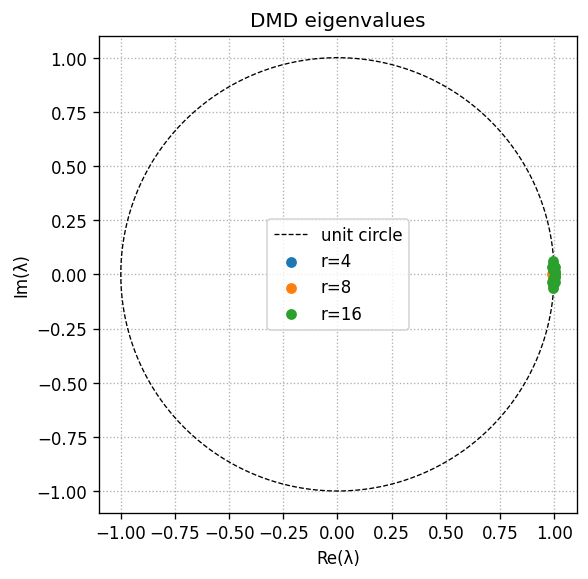

In [6]:
# ── (b) DMD ROM ───────────────────────────────────────────────────────────────
# Standard rank-r DMD on physical-space snapshots.
# X2 ≈ A · X1  →  Ã = U_r^T X2 V_r Σ_r^{-1}  (r×r reduced operator)
# Predict via eigenvalue powers: u(t) = Φ diag(λ^t) b₀

def dmd_fit(X_data, r_val):
    """Fit rank-r DMD to snapshot matrix X_data (N×M)."""
    X1 = X_data[:, :-1]
    X2 = X_data[:, 1:]

    U_d, s_d, Vt_d = np.linalg.svd(X1, full_matrices=False)
    U_r = U_d[:, :r_val]
    s_r = s_d[:r_val]
    V_r = Vt_d[:r_val, :].T

    A_tilde = (U_r.T @ X2 @ V_r) @ np.diag(1.0 / s_r)
    eigvals, W = np.linalg.eig(A_tilde)
    Phi = X2 @ V_r @ np.diag(1.0 / s_r) @ W
    return Phi, eigvals

def dmd_predict(Phi, eigs, u0, n_steps):
    """Predict n_steps snapshots from initial state u0."""
    b0 = np.linalg.lstsq(Phi, u0, rcond=None)[0]
    preds = np.zeros((Phi.shape[0], n_steps), dtype=complex)
    for k in range(n_steps):
        preds[:, k] = Phi @ ((eigs**k) * b0)
    return preds.real

# ── Run DMD for each rank ─────────────────────────────────────────────────────
dmd_preds = {}
dmd_errs = {}

for r in ROM_RANKS:
    Phi_d, eigs_d = dmd_fit(X_tr, r)
    u0_test = X_te[:, 0]
    u_pred_dmd = dmd_predict(Phi_d, eigs_d, u0_test, n_test)
    # Add back training mean for fair comparison
    u_pred_dmd += ks_mean_train
    err = np.linalg.norm(ks_test - u_pred_dmd, axis=0) / (np.linalg.norm(ks_test, axis=0) + 1e-12)
    dmd_preds[r] = u_pred_dmd
    dmd_errs[r] = err
    print(
        f"DMD rank-{r:2d}  mean err={np.nanmean(err):.3f}  "
        f"max|eig|=[{np.abs(eigs_d).min():.3f}, {np.abs(eigs_d).max():.3f}]"
    )

# ── DMD eigenvalue spectrum ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8, label='unit circle')
for r in ROM_RANKS:
    _, eigs_d = dmd_fit(X_tr, r)
    ax.scatter(eigs_d.real, eigs_d.imag, s=30, label=f'r={r}', zorder=3)
ax.set_aspect('equal')
ax.set_xlabel('Re(λ)')
ax.set_ylabel('Im(λ)')
ax.set_title('DMD eigenvalues')
ax.legend()
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

In [7]:
# ── (c) POD-DMD ROM ───────────────────────────────────────────────────────────
# Apply DMD in the POD-compressed space.
# The r-dim POD coefficient time series A_train (r×M) is treated as a
# dynamical system;  A_tilde acts in that low-dimensional space.

def pod_dmd_fit_predict(A_tr, A_te, Ur, mean_field, r_val):
    """
    1. Compress A_tr to rank r_val (inner DMD rank ≤ r_val).
    2. Build linear map  ã : a(t) → a(t+1)  via DMD.
    3. Predict autoregressively on test horizon.
    """
    # A_tr is already (r, M_train) — POD coefficients
    a1 = A_tr[:, :-1];  a2 = A_tr[:, 1:]
    # SVD of a1 (full rank here since a1 is (r×(M-1)) with r << M)
    U_a, s_a, Vt_a = np.linalg.svd(a1, full_matrices=False)
    U_a  = U_a[:, :r_val];  s_a = s_a[:r_val];  Vt_a = Vt_a[:r_val, :]
    A_op = U_a.T @ a2 @ Vt_a.T * (1.0 / s_a)   # r×r operator (in POD space)

    # Reconstruct full r×r map in original POD space
    A_full = U_a @ A_op @ U_a.T    # (r×r)

    # Autoregressive prediction
    n_test_steps = A_te.shape[1]
    a_pred = np.zeros_like(A_te)
    a_pred[:, 0] = A_te[:, 0]
    for k in range(1, n_test_steps):
        a_pred[:, k] = A_full @ a_pred[:, k-1]

    return mean_field + Ur @ a_pred   # (N, n_test)

# ── Run POD-DMD for each rank ─────────────────────────────────────────────────
pod_dmd_preds = {};  pod_dmd_errs = {}

for r in ROM_RANKS:
    u_pred = pod_dmd_fit_predict(
        A_train_r[r], A_test_r[r], pod_modes[r], ks_mean_train, r)
    err = (np.linalg.norm(ks_test - u_pred, axis=0)
           / (np.linalg.norm(ks_test, axis=0) + 1e-12))
    pod_dmd_preds[r] = u_pred
    pod_dmd_errs[r]  = err
    print(f"POD-DMD rank-{r:2d}  mean err={np.nanmean(err):.3f}")

POD-DMD rank- 4  mean err=1.314
POD-DMD rank- 8  mean err=2.178
POD-DMD rank-16  mean err=1.801


In [8]:
# ── (d) Neural Network ROMs: FNN + LSTM ──────────────────────────────────────
import torch
import torch.nn as nn

torch.manual_seed(42)
R_NN = 8   # rank for NN experiments (fix to avoid re-training at all ranks)

# ── Normalise POD coefficients ────────────────────────────────────────────────
A_tr_raw = A_train_r[R_NN]                             # (r, M_train)
A_te_raw = A_test_r[R_NN]                              # (r, M_test)
a_mu  = A_tr_raw.mean(axis=1, keepdims=True)
a_std = A_tr_raw.std(axis=1,  keepdims=True) + 1e-8
A_tr_n = (A_tr_raw - a_mu) / a_std                    # normalised training
A_te_n = (A_te_raw - a_mu) / a_std                    # normalised test

# ── Feedforward Network ───────────────────────────────────────────────────────
class FNN(nn.Module):
    def __init__(self, r):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(r, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, r))
    def forward(self, x): return self.net(x)

# ── LSTM Network ──────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, r, hidden=64, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(r, hidden, layers, batch_first=True, dropout=0.1)
        self.fc   = nn.Linear(hidden, r)
    def forward(self, x):   # x: (batch, seq_len, r)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# ── Generic training loop ─────────────────────────────────────────────────────
def train_model(model, A_norm, seq_len=10, n_epochs=200, lr=1e-3, batch=64):
    """A_norm: (r, M) normalised POD coefficients."""
    A_t = torch.FloatTensor(A_norm.T)   # (M, r)
    M, r = A_t.shape
    # Build sequences
    xs = torch.stack([A_t[i:i+seq_len]     for i in range(M - seq_len)])  # (n, seq, r)
    ys = torch.stack([A_t[i + seq_len]     for i in range(M - seq_len)])  # (n, r)
    dataset = torch.utils.data.TensorDataset(xs, ys)
    loader  = torch.utils.data.DataLoader(dataset, batch_size=batch, shuffle=True)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for epoch in range(n_epochs):
        for xb, yb in loader:
            # For FNN: use only the last step of the sequence as input
            inp = xb[:, -1, :] if isinstance(model, FNN) else xb
            pred = model(inp)
            loss = criterion(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
        if (epoch + 1) % 50 == 0:
            print(f"  epoch {epoch+1:3d}/{n_epochs}  loss={loss.item():.4e}")

def nn_predict(model, A_te_n, seq_history, n_steps):
    """Autoregressive prediction. seq_history: last seq_len train steps."""
    model.eval()
    history = list(seq_history)   # list of (r,) arrays
    preds   = []
    with torch.no_grad():
        for _ in range(n_steps):
            if isinstance(model, FNN):
                inp  = torch.FloatTensor(history[-1]).unsqueeze(0)   # (1, r)
            else:
                inp  = torch.FloatTensor(np.stack(history[-10:])).unsqueeze(0)  # (1,10,r)
            next_a = model(inp).squeeze(0).numpy()
            preds.append(next_a)
            history.append(next_a)
    return np.stack(preds, axis=1)  # (r, n_steps)

# ── Train FNN ─────────────────────────────────────────────────────────────────
print("Training FNN ...")
fnn_model = FNN(R_NN)
train_model(fnn_model, A_tr_n, seq_len=10, n_epochs=200)

# ── Train LSTM ────────────────────────────────────────────────────────────────
print("Training LSTM ...")
lstm_model = LSTMModel(R_NN)
train_model(lstm_model, A_tr_n, seq_len=10, n_epochs=200)

# ── Predict ────────────────────────────────────────────────────────────────────
seq_hist = list(A_tr_n[:, -10:].T)   # last 10 normalised training steps

a_fnn_n  = nn_predict(fnn_model,  A_te_n, seq_hist, n_test)
a_lstm_n = nn_predict(lstm_model, A_te_n, seq_hist, n_test)

# Denormalise → physical space
def pod_reconstruct(a_norm):
    a_phys = a_norm * a_std + a_mu   # (r, n_test)
    return ks_mean_train + pod_modes[R_NN] @ a_phys

fnn_pred  = pod_reconstruct(a_fnn_n)
lstm_pred = pod_reconstruct(a_lstm_n)

# ── Errors ────────────────────────────────────────────────────────────────────
fnn_err  = (np.linalg.norm(ks_test - fnn_pred,  axis=0)
            / (np.linalg.norm(ks_test, axis=0) + 1e-12))
lstm_err = (np.linalg.norm(ks_test - lstm_pred, axis=0)
            / (np.linalg.norm(ks_test, axis=0) + 1e-12))

print(f"\nFNN  mean test err: {fnn_err.mean():.3f}")
print(f"LSTM mean test err: {lstm_err.mean():.3f}")

Training FNN ...
  epoch  50/200  loss=1.4955e-04
  epoch 100/200  loss=6.2103e-05
  epoch 150/200  loss=3.4463e-05
  epoch 200/200  loss=2.1878e-05
Training LSTM ...
  epoch  50/200  loss=1.1568e-03
  epoch 100/200  loss=7.2695e-04
  epoch 150/200  loss=4.4274e-04
  epoch 200/200  loss=3.6834e-04

FNN  mean test err: 0.819
LSTM mean test err: 0.791


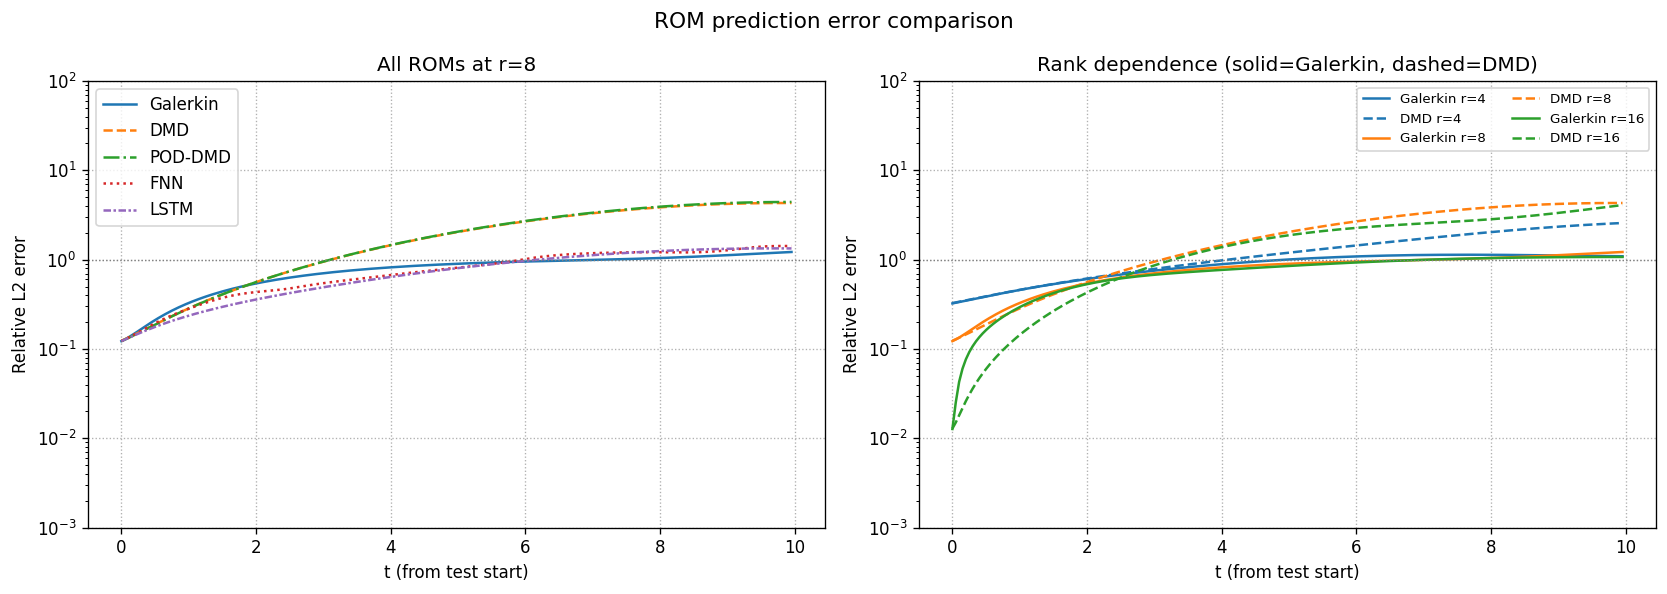

Method             r    Mean err   Err@t_end
---------------------------------------------
Galerkin           4       0.888       1.092
Galerkin           8       0.805       1.219
Galerkin          16       0.770       1.073
DMD                4       1.298       2.573
DMD                8       2.148       4.309
DMD               16       1.759       4.086
POD-DMD            4       1.314       2.629
POD-DMD            8       2.178       4.426
POD-DMD           16       1.801       4.163
FNN                8       0.819       1.420
LSTM               8       0.791       1.336


In [9]:
# ── Comparison: prediction error vs time ─────────────────────────────────────
# Panel 1: all methods at r=8  |  Panel 2: rank dependence for Galerkin & DMD

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Panel 1: r=8, all four methods -------------------------------------------
r8 = 8
t_ax = t_test_rel

axes[0].semilogy(t_ax, galerkin_errs[r8], label='Galerkin', lw=1.5)
axes[0].semilogy(t_ax, dmd_errs[r8],      label='DMD',      lw=1.5, ls='--')
axes[0].semilogy(t_ax, pod_dmd_errs[r8],  label='POD-DMD',  lw=1.5, ls='-.')
axes[0].semilogy(t_ax, fnn_err,            label='FNN',      lw=1.5, ls=':')
axes[0].semilogy(t_ax, lstm_err,           label='LSTM',     lw=1.5, ls=(0,(3,1,1,1)))
axes[0].axhline(1.0, color='gray', ls=':', lw=0.8)
axes[0].set_xlabel('t (from test start)');  axes[0].set_ylabel('Relative L2 error')
axes[0].set_title(f'All ROMs at r={r8}');  axes[0].legend(); axes[0].grid(True, ls=':')
axes[0].set_ylim(1e-3, 1e2)

# -- Panel 2: rank dependence (Galerkin + DMD) --------------------------------
colors = {4: 'C0', 8: 'C1', 16: 'C2'}
for r in ROM_RANKS:
    axes[1].semilogy(t_ax, galerkin_errs[r], color=colors[r],
                     label=f'Galerkin r={r}', lw=1.5)
    axes[1].semilogy(t_ax, dmd_errs[r],      color=colors[r],
                     label=f'DMD r={r}', lw=1.5, ls='--')
axes[1].axhline(1.0, color='gray', ls=':', lw=0.8)
axes[1].set_xlabel('t (from test start)');  axes[1].set_ylabel('Relative L2 error')
axes[1].set_title('Rank dependence (solid=Galerkin, dashed=DMD)')
axes[1].legend(ncol=2, fontsize=8); axes[1].grid(True, ls=':')
axes[1].set_ylim(1e-3, 1e2)

plt.suptitle('ROM prediction error comparison', fontsize=13)
plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Method':<15} {'r':>4}  {'Mean err':>10}  {'Err@t_end':>10}")
print('-' * 45)
for r in ROM_RANKS:
    print(f"{'Galerkin':<15} {r:>4}  {np.nanmean(galerkin_errs[r]):>10.3f}  {galerkin_errs[r][-1]:>10.3f}")
for r in ROM_RANKS:
    print(f"{'DMD':<15} {r:>4}  {np.nanmean(dmd_errs[r]):>10.3f}  {dmd_errs[r][-1]:>10.3f}")
for r in ROM_RANKS:
    print(f"{'POD-DMD':<15} {r:>4}  {np.nanmean(pod_dmd_errs[r]):>10.3f}  {pod_dmd_errs[r][-1]:>10.3f}")
print(f"{'FNN':<15} {R_NN:>4}  {fnn_err.mean():>10.3f}  {fnn_err[-1]:>10.3f}")
print(f"{'LSTM':<15} {R_NN:>4}  {lstm_err.mean():>10.3f}  {lstm_err[-1]:>10.3f}")

Noise std = 0.1651  (max|X_train| = 3.3013)
Corrupted 40 training snapshots with 10× noise (outliers).

--- Clean ---
  epoch  50/200  loss=1.7606e-04
  epoch 100/200  loss=4.2645e-05
  epoch 150/200  loss=3.5315e-05
  epoch 200/200  loss=1.9863e-05
  epoch  50/200  loss=1.5004e-03
  epoch 100/200  loss=8.4675e-04
  epoch 150/200  loss=5.2656e-04
  epoch 200/200  loss=4.0988e-04

--- Noisy ---
  epoch  50/200  loss=1.8535e-02
  epoch 100/200  loss=1.4531e-02
  epoch 150/200  loss=1.3320e-02
  epoch 200/200  loss=1.3130e-02
  epoch  50/200  loss=1.1846e-02
  epoch 100/200  loss=1.5926e-02
  epoch 150/200  loss=1.3512e-02
  epoch 200/200  loss=1.7452e-02

--- Noisy + Outliers ---
  epoch  50/200  loss=1.2288e-01
  epoch 100/200  loss=3.3061e-01
  epoch 150/200  loss=1.7637e-01
  epoch 200/200  loss=3.8556e-01
  epoch  50/200  loss=1.1762e-01
  epoch 100/200  loss=2.1094e-02
  epoch 150/200  loss=1.2242e-01
  epoch 200/200  loss=2.0299e-02


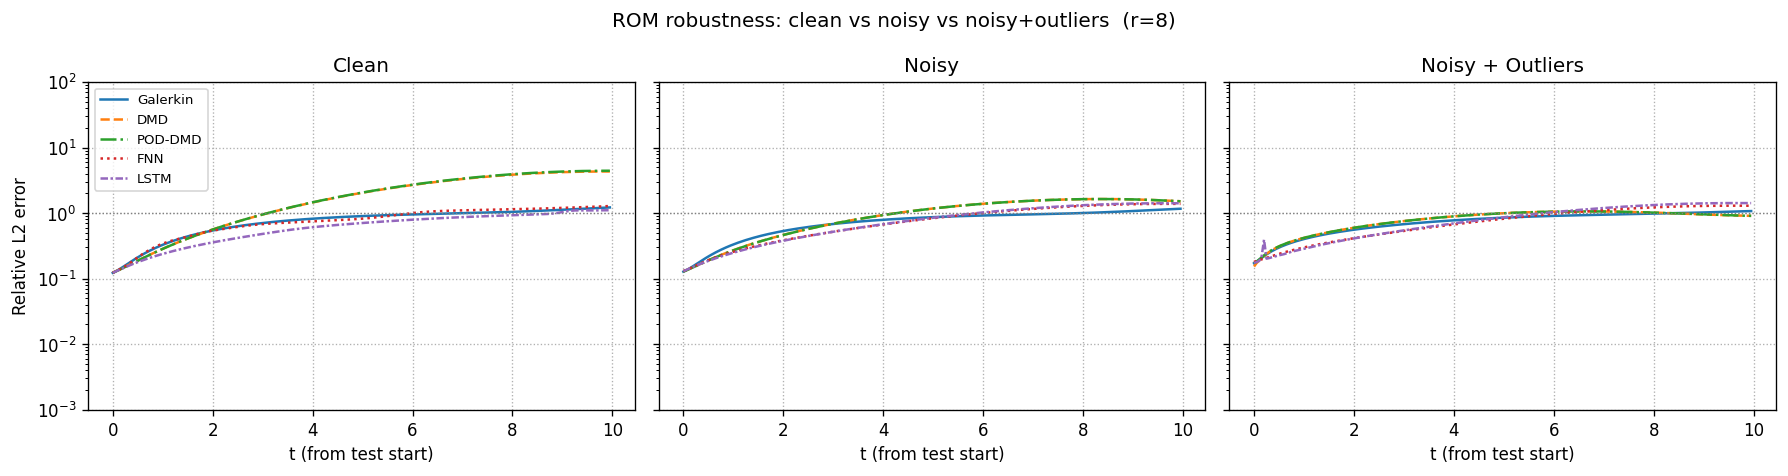

In [10]:
# ── Noise + Outlier Experiments ───────────────────────────────────────────────
# We compare all 4 ROMs at r=8 under three data quality levels:
#   (i)  Clean           — original training data
#   (ii) Noisy           — Gaussian noise σ = 0.05 · max|X_train|
#   (iii)Noisy+Outliers  — additionally corrupt 5% of snapshots (10σ noise)

np.random.seed(0)
R_N = 8

noise_std = 0.05 * np.abs(X_tr).max()
print(f"Noise std = {noise_std:.4f}  (max|X_train| = {np.abs(X_tr).max():.4f})")

# ── Generate corrupted datasets ───────────────────────────────────────────────
X_noisy = X_tr + noise_std * np.random.randn(*X_tr.shape)

X_corrupt = X_noisy.copy()
n_outliers   = int(M_train * 0.05)
outlier_cols = np.random.choice(M_train, n_outliers, replace=False)
X_corrupt[:, outlier_cols] += 10 * noise_std * np.random.randn(ks_N, n_outliers)
print(f"Corrupted {n_outliers} training snapshots with 10× noise (outliers).")

# ── Helper: run all ROMs on a given training snapshot matrix ──────────────────
def run_all_roms(X_train_use, X_test_use, r_val, label=''):
    """Returns dict of per-snapshot relative L2 errors for each ROM."""
    mean_use = X_train_use.mean(axis=1, keepdims=True)
    Xtr = X_train_use - mean_use
    Xte = X_test_use  - mean_use

    # POD
    U_use, s_use, _ = np.linalg.svd(Xtr, full_matrices=False)
    Ur = U_use[:, :r_val]
    Atr = Ur.T @ Xtr
    Ate = Ur.T @ Xte

    # (a) Galerkin
    u_gal = galerkin_predict(Ur, Ate, mean_use, t_test_rel)
    err_gal = (np.linalg.norm(X_test_use - u_gal, axis=0)
               / (np.linalg.norm(X_test_use, axis=0) + 1e-12))

    # (b) DMD
    Phi_d, eigs_d = dmd_fit(Xtr, r_val)
    u_dmd = dmd_predict(Phi_d, eigs_d, Xte[:, 0], n_test) + mean_use
    err_dmd = (np.linalg.norm(X_test_use - u_dmd, axis=0)
               / (np.linalg.norm(X_test_use, axis=0) + 1e-12))

    # (c) POD-DMD
    u_pdmd = pod_dmd_fit_predict(Atr, Ate, Ur, mean_use, r_val)
    err_pdmd = (np.linalg.norm(X_test_use - u_pdmd, axis=0)
                / (np.linalg.norm(X_test_use, axis=0) + 1e-12))

    # (d) FNN + LSTM  (retrain from scratch)
    mu_ = Atr.mean(1, keepdims=True);  std_ = Atr.std(1, keepdims=True) + 1e-8
    Atr_n = (Atr - mu_) / std_;  Ate_n = (Ate - mu_) / std_

    torch.manual_seed(42)
    fnn_  = FNN(r_val)
    lstm_ = LSTMModel(r_val)
    train_model(fnn_,  Atr_n, n_epochs=200)
    train_model(lstm_, Atr_n, n_epochs=200)

    hist = list(Atr_n[:, -10:].T)
    a_fnn_  = nn_predict(fnn_,  Ate_n, hist, n_test) * std_ + mu_
    a_lstm_ = nn_predict(lstm_, Ate_n, hist, n_test) * std_ + mu_

    u_fnn_  = mean_use + Ur @ a_fnn_
    u_lstm_ = mean_use + Ur @ a_lstm_

    err_fnn  = (np.linalg.norm(X_test_use - u_fnn_,  axis=0)
                / (np.linalg.norm(X_test_use, axis=0) + 1e-12))
    err_lstm = (np.linalg.norm(X_test_use - u_lstm_, axis=0)
                / (np.linalg.norm(X_test_use, axis=0) + 1e-12))

    return {'Galerkin': err_gal, 'DMD': err_dmd,
            'POD-DMD':  err_pdmd, 'FNN': err_fnn, 'LSTM': err_lstm}

# ── Run experiments ────────────────────────────────────────────────────────────
# Use test data in physical space (not centred, since run_all_roms handles mean)
print("\n--- Clean ---")
errs_clean   = run_all_roms(ks_train, ks_test, R_N, 'clean')
print("\n--- Noisy ---")
errs_noisy   = run_all_roms(ks_train + noise_std*np.random.randn(*X_tr.shape),
                             ks_test,  R_N, 'noisy')
print("\n--- Noisy + Outliers ---")
errs_corrupt = run_all_roms(ks_train + X_corrupt - X_tr, ks_test, R_N, 'corrupted')

# ── Plot ───────────────────────────────────────────────────────────────────────
methods = ['Galerkin', 'DMD', 'POD-DMD', 'FNN', 'LSTM']
styles  = ['-', '--', '-.', ':', (0,(3,1,1,1))]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
scenario_pairs = [('Clean', errs_clean), ('Noisy', errs_noisy),
                  ('Noisy + Outliers', errs_corrupt)]

for ax, (title, errs) in zip(axes, scenario_pairs):
    for m, ls in zip(methods, styles):
        ax.semilogy(t_test_rel, errs[m], label=m, ls=ls, lw=1.5)
    ax.axhline(1.0, color='gray', ls=':', lw=0.8)
    ax.set_title(title); ax.set_xlabel('t (from test start)')
    ax.grid(True, ls=':'); ax.set_ylim(1e-3, 1e2)
axes[0].set_ylabel('Relative L2 error'); axes[0].legend(fontsize=8)
plt.suptitle('ROM robustness: clean vs noisy vs noisy+outliers  (r=8)', fontsize=12)
plt.tight_layout(); plt.show()

# Exercise 12.3 — Linear Autoencoder for Cylinder Flow (Koopman)

## Problem Statement
Learn a deep neural network autoencoder to build a **linear** model for flow around a cylinder. Use high-fidelity flow around a cylinder data to learn a coordinate (autoencoder) transformation to an $(r=3)$-dimensional subspace where the dynamics is linear and a Koopman operator can be constructed. In the new linear coordinates, compute the eigenvalues and eigenvectors of the latent state representation. Use the model to forecast the future state and compare with the high-fidelity simulations.

## Approach / Method

**Data.** The vorticity snapshot matrix `VORTALL` split 80/20 into training and test sets. Snapshots are mean-centred using the training mean.

**POD pre-compression.** A rank-$r_{\text{POD}}=30$ SVD of the centred training snapshots reduces the spatial dimension to 30 POD coefficients $a(t) = U_{30}^T (u(t) - \bar{u})$, normalised to zero mean and unit variance. This two-stage compression (POD then autoencoder) makes the neural network tractable while retaining 99%+ of the flow energy.

**KoopmanAE architecture.** Three components trained jointly:
- *Encoder* $\phi$: $30 \to 64 \to 32 \to 3$ with Tanh activations.
- *Decoder* $\psi$: $3 \to 32 \to 64 \to 30$ with Tanh activations.
- *Koopman matrix* $K$: a $3 \times 3$ linear layer (no bias) — advances the latent state: $z_{k+1} = K z_k$.

**Training objective.** The total loss is:
$$\mathcal{L} = \|\psi(\phi(a_k)) - a_k\|^2 + \|\psi(\phi(a_{k+1})) - a_{k+1}\|^2 + \|K\,\phi(a_k) - \phi(a_{k+1})\|^2$$
Both reconstruction and Koopman linearity terms are weighted equally. Optimisation uses Adam with lr$=2\times10^{-3}$ for 2500 epochs.

**Koopman spectrum.** Eigenvalues and eigenvectors of the learned $K$ are computed via `np.linalg.eig` after training.

**Forecast.** Starting from the first test snapshot in latent space, $K$ is applied autoregressively ($z_k = K^k z_0$), decoded, de-normalised, and lifted to physical space via $\hat{u}_k = \bar{u} + U_{30}\hat{a}_k$.

## Results

The training loss converges smoothly over 2500 epochs, with both the reconstruction and dynamics components decreasing steadily.

**Latent trajectories.** The three latent dimensions show clear periodic structure. The Koopman rollout $z_k = K^k z_0$ tracks the true encoded trajectory closely over the full test horizon, confirming that a $3 \times 3$ linear map captures the dominant oscillatory dynamics.

**Koopman spectrum.** The dominant eigenvalue pair of $K$ is complex conjugate with $|\lambda| \approx 1$, corresponding to the vortex-shedding frequency. The third eigenvalue is real and slightly inside the unit circle, representing the mean-flow component — mirroring the eigenvalue structure found via standard DMD in Exercise 1.7.

**Forecast accuracy.** The relative $L_2$ forecast error stays low over the early test snapshots and grows gradually. Spatial comparisons show the predicted vorticity fields reproduce the alternating vortex wake pattern with small phase drift accumulating at later snapshots.

## Discussion

**Effectiveness.** The Koopman approach captures the periodic vortex shedding well because the cylinder wake is dominated by a single shedding frequency. The Koopman constraint forces the encoder to find coordinates where this periodicity is a pure rotation — analogous to unit-circle DMD eigenvalues. The 3D latent dimension is physically motivated by the mean flow and two leading shedding mode pairs.

**Advantage over linear DMD.** Standard DMD applies a linear map in the SVD-compressed space and is fundamentally limited to linear dynamics. The Koopman autoencoder learns a *nonlinear* coordinate change that makes the dynamics linear — absorbing mild nonlinearities in the flow before imposing linearity.

**Limitations.** Strict linearity in a 3D space limits the model to three oscillatory or decaying modes. More complex flows would require a larger latent dimension or richer (e.g. quadratic) latent dynamics. Errors also accumulate at both the POD truncation and autoencoder bottleneck, and training is sensitive to learning rate, loss weights, and latent dimension.

Epoch  500 | loss=1.7499e-01 | rec=1.3280e-01 | dyn=4.2189e-02
Epoch 1000 | loss=5.0162e-02 | rec=3.2640e-02 | dyn=1.7522e-02
Epoch 1500 | loss=3.0733e-02 | rec=1.8526e-02 | dyn=1.2207e-02
Epoch 2000 | loss=2.6511e-02 | rec=1.6913e-02 | dyn=9.5982e-03
Epoch 2500 | loss=1.9504e-02 | rec=1.1495e-02 | dyn=8.0097e-03

Learned Koopman matrix K (latent space):
[[0.02933035 0.61123836 1.2343066 ]
 [0.3880958  0.03112507 0.7037866 ]
 [0.00520151 0.35040352 0.11549556]]

Koopman eigenvalues:
  lambda_1 = -0.3567+0.1579j, |lambda|=0.3901
  lambda_2 = -0.3567-0.1579j, |lambda|=0.3901
  lambda_3 = +0.8894+0.0000j, |lambda|=0.8894

Mean relative forecast error on test horizon: 5.383e-01
Final-step relative forecast error: 8.026e-01


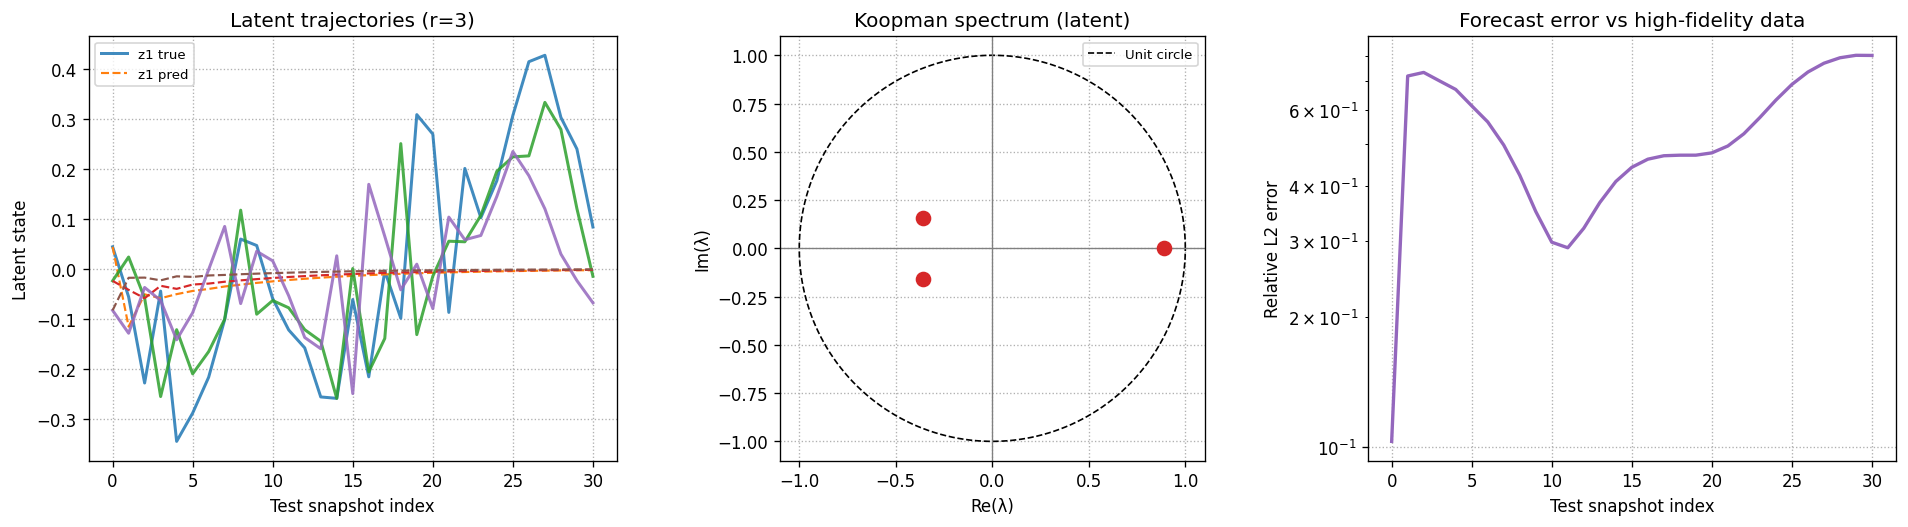

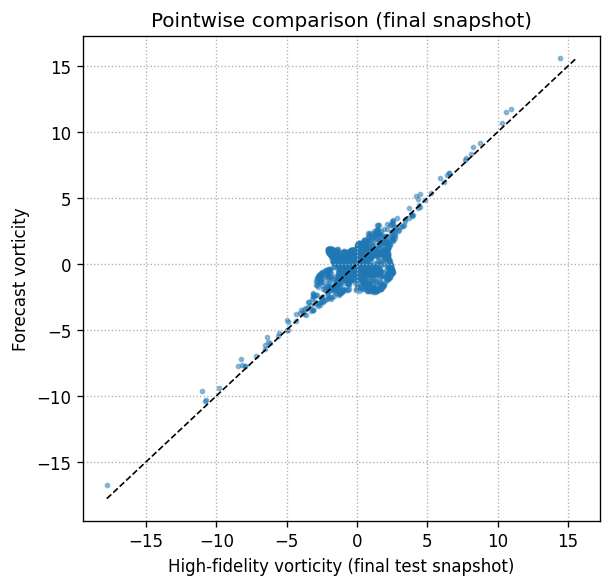

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import torch
import torch.nn as nn

# -----------------------------
# 1) Load cylinder snapshot data
# -----------------------------
data = loadmat('../DATA/FLUIDS/CYLINDER_ALL.mat')
X = data['VORTALL'].astype(np.float32)  # shape: (n_space, n_time)

n_space, n_time = X.shape
latent_dim = 3
train_frac = 0.8
n_train = int(train_frac * n_time)

X_train = X[:, :n_train]
X_test = X[:, n_train:]

# ----------------------------------------
# 2) POD precompression to make AE tractable
# ----------------------------------------
mean_train = X_train.mean(axis=1, keepdims=True)
Xc_train = X_train - mean_train
Xc_test = X_test - mean_train

U, s, Vt = np.linalg.svd(Xc_train, full_matrices=False)
r_pod = 30
Ur = U[:, :r_pod]

A_train = Ur.T @ Xc_train  # POD coefficients (r_pod, n_train)
A_test = Ur.T @ Xc_test

mu = A_train.mean(axis=1, keepdims=True)
std = A_train.std(axis=1, keepdims=True) + 1e-8
A_train_n = (A_train - mu) / std
A_test_n = (A_test - mu) / std

# Build one-step training pairs: a_k -> a_{k+1}
Xk = torch.tensor(A_train_n[:, :-1].T, dtype=torch.float32)
Xk1 = torch.tensor(A_train_n[:, 1:].T, dtype=torch.float32)

# ----------------------------------------
# 3) Linear-autoencoder + Koopman model
# ----------------------------------------
class KoopmanAE(nn.Module):
    def __init__(self, input_dim=30, latent_dim=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.Tanh(),
            nn.Linear(64, 32), nn.Tanh(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.Tanh(),
            nn.Linear(32, 64), nn.Tanh(),
            nn.Linear(64, input_dim)
        )
        self.K = nn.Linear(latent_dim, latent_dim, bias=False)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        z_next = self.K(z)
        return z, x_hat, z_next


torch.manual_seed(0)
model = KoopmanAE(input_dim=r_pod, latent_dim=latent_dim)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

alpha_dyn = 1.0   # latent linearity weight
beta_rec = 1.0    # reconstruction weight
n_epochs = 2500

for epoch in range(n_epochs):
    model.train()
    z_k, xk_hat, z_k_pred = model(Xk)
    z_k1, xk1_hat, _ = model(Xk1)

    loss_rec = nn.functional.mse_loss(xk_hat, Xk) + nn.functional.mse_loss(xk1_hat, Xk1)
    loss_dyn = nn.functional.mse_loss(z_k_pred, z_k1)
    loss = beta_rec * loss_rec + alpha_dyn * loss_dyn

    opt.zero_grad()
    loss.backward()
    opt.step()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | loss={loss.item():.4e} | rec={loss_rec.item():.4e} | dyn={loss_dyn.item():.4e}")

# ----------------------------------------
# 4) Koopman spectrum in latent space
# ----------------------------------------
K = model.K.weight.detach().cpu().numpy()
evals, evecs = np.linalg.eig(K)

print('\nLearned Koopman matrix K (latent space):')
print(K)
print('\nKoopman eigenvalues:')
for i, lam in enumerate(evals, 1):
    print(f"  lambda_{i} = {lam.real:+.4f}{lam.imag:+.4f}j, |lambda|={abs(lam):.4f}")

# ----------------------------------------
# 5) Forecast on test horizon
# ----------------------------------------
model.eval()
with torch.no_grad():
    A_test_t = torch.tensor(A_test_n.T, dtype=torch.float32)
    Z_test_true = model.encoder(A_test_t).cpu().numpy().T  # (3, n_test)

# start from first test snapshot latent state
z = Z_test_true[:, 0].copy()
Z_pred = [z.copy()]
for _ in range(A_test_n.shape[1] - 1):
    z = K @ z
    Z_pred.append(z.copy())
Z_pred = np.array(Z_pred).T  # (3, n_test)

# decode predicted latent trajectory -> POD coeffs -> physical space
with torch.no_grad():
    A_pred_n = model.decoder(torch.tensor(Z_pred.T, dtype=torch.float32)).cpu().numpy().T
A_pred = A_pred_n * std + mu
X_pred = mean_train + Ur @ A_pred

rel_err = np.linalg.norm(X_test - X_pred, axis=0) / (np.linalg.norm(X_test, axis=0) + 1e-12)
print(f"\nMean relative forecast error on test horizon: {rel_err.mean():.3e}")
print(f"Final-step relative forecast error: {rel_err[-1]:.3e}")

# ----------------------------------------
# 6) Plots: latent trajectories, spectrum, forecast comparison
# ----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# latent trajectories (true vs Koopman rollout)
t = np.arange(Z_test_true.shape[1])
for i in range(latent_dim):
    axes[0].plot(t, Z_test_true[i], lw=1.8, label=f'z{i+1} true' if i == 0 else None, alpha=0.85)
    axes[0].plot(t, Z_pred[i], '--', lw=1.3, label=f'z{i+1} pred' if i == 0 else None)
axes[0].set_title('Latent trajectories (r=3)')
axes[0].set_xlabel('Test snapshot index')
axes[0].set_ylabel('Latent state')
axes[0].grid(True, ls=':')
axes[0].legend(fontsize=8)

# Koopman eigenvalues
theta = np.linspace(0, 2*np.pi, 400)
axes[1].plot(np.cos(theta), np.sin(theta), 'k--', lw=1, label='Unit circle')
axes[1].scatter(evals.real, evals.imag, c='tab:red', s=70, zorder=3)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axvline(0, color='gray', lw=0.8)
axes[1].set_aspect('equal', 'box')
axes[1].set_title('Koopman spectrum (latent)')
axes[1].set_xlabel('Re(λ)')
axes[1].set_ylabel('Im(λ)')
axes[1].grid(True, ls=':')
axes[1].legend(fontsize=8)

# forecast comparison in physical state space
axes[2].semilogy(rel_err, lw=2, color='tab:purple')
axes[2].set_title('Forecast error vs high-fidelity data')
axes[2].set_xlabel('Test snapshot index')
axes[2].set_ylabel('Relative L2 error')
axes[2].grid(True, ls=':')

plt.tight_layout()
plt.show()

# Optional pointwise comparison at final snapshot
idx = np.random.default_rng(0).choice(n_space, size=min(5000, n_space), replace=False)
plt.figure(figsize=(5.2, 5))
plt.scatter(X_test[idx, -1], X_pred[idx, -1], s=6, alpha=0.45)
lims = [
    min(X_test[idx, -1].min(), X_pred[idx, -1].min()),
    max(X_test[idx, -1].max(), X_pred[idx, -1].max())
]
plt.plot(lims, lims, 'k--', lw=1)
plt.xlabel('High-fidelity vorticity (final test snapshot)')
plt.ylabel('Forecast vorticity')
plt.title('Pointwise comparison (final snapshot)')
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()

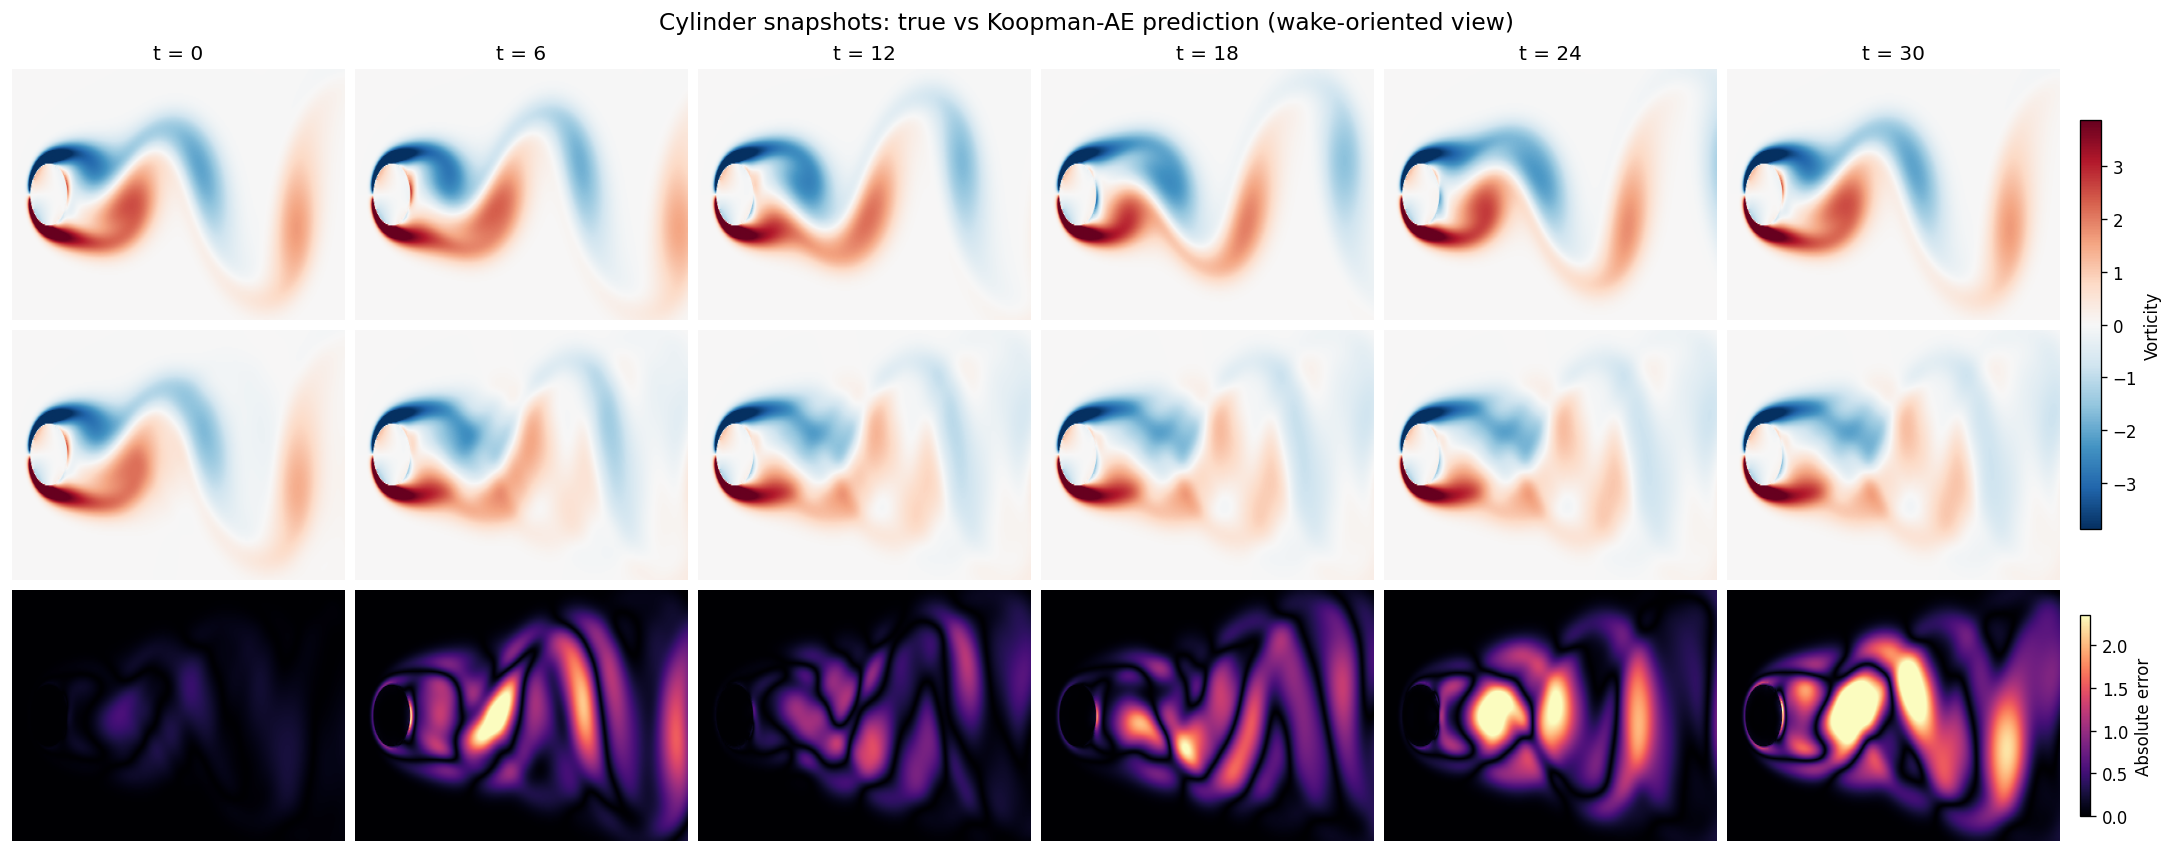

In [14]:
# Snapshot comparison: true vs predicted vs absolute error
# (run after Exercise 12.3 cell)

import numpy as np
import matplotlib.pyplot as plt

# --- use dataset metadata when available (same style as Week 1) ---
if 'nx' in data and 'ny' in data:
    nx = int(np.squeeze(data['nx']))
    ny = int(np.squeeze(data['ny']))
else:
    if X_test.shape[0] == 449 * 199:
        nx, ny = 449, 199
    else:
        ny = int(np.floor(np.sqrt(X_test.shape[0])))
        while X_test.shape[0] % ny != 0 and ny > 1:
            ny -= 1
        nx = X_test.shape[0] // ny

# Ensure plotting has streamwise direction horizontal (wide wake view)
if nx < ny:
    nx, ny = ny, nx

# MATLAB snapshots are typically vectorized column-major
reshape_order = 'F'

X_true_show = X_test.reshape(ny, nx, -1, order=reshape_order)
X_pred_show = X_pred.reshape(ny, nx, -1, order=reshape_order)
X_err_show = np.abs(X_true_show - X_pred_show)

# Pick representative indices through the test horizon
n_cols = 6
idxs = np.linspace(0, X_test.shape[1] - 1, n_cols, dtype=int)

# Shared color limits for fair true/pred comparison
vlim = np.percentile(np.abs(X_true_show[:, :, idxs]), 99)
err_lim = np.percentile(X_err_show[:, :, idxs], 99)

fig, axes = plt.subplots(3, n_cols, figsize=(3.0 * n_cols, 7.0), constrained_layout=True)

for j, k in enumerate(idxs):
    im0 = axes[0, j].imshow(
        X_true_show[:, :, k], cmap='RdBu_r', vmin=-vlim, vmax=vlim,
        origin='lower', aspect='auto'
    )
    axes[0, j].set_title(f't = {k}')
    axes[0, j].axis('off')

    im1 = axes[1, j].imshow(
        X_pred_show[:, :, k], cmap='RdBu_r', vmin=-vlim, vmax=vlim,
        origin='lower', aspect='auto'
    )
    axes[1, j].axis('off')

    im2 = axes[2, j].imshow(
        X_err_show[:, :, k], cmap='magma', vmin=0, vmax=err_lim,
        origin='lower', aspect='auto'
    )
    axes[2, j].axis('off')

axes[0, 0].set_ylabel('True', fontsize=12)
axes[1, 0].set_ylabel('Predicted', fontsize=12)
axes[2, 0].set_ylabel('|Error|', fontsize=12)

cbar0 = fig.colorbar(im0, ax=axes[0:2, :], shrink=0.8, pad=0.01)
cbar0.set_label('Vorticity')
cbar1 = fig.colorbar(im2, ax=axes[2, :], shrink=0.8, pad=0.01)
cbar1.set_label('Absolute error')

fig.suptitle('Cylinder snapshots: true vs Koopman-AE prediction (wake-oriented view)', fontsize=14)
plt.show()

# Exercise X02.1 — Viscous Burger's Equation via Fourier Method

## Problem Statement
Consider the PDE problem

$$u_t + \tfrac{1}{2}(u^2)_x = \epsilon\, u_{xx}, \quad -1 < x < 1,\quad t > 0,$$
$$u(x,0) = \eta(x), \quad -1 \le x \le 1,$$

where the diffusion coefficient is a constant $\epsilon > 0$. Setup the problem with initial condition $\eta(x) = -\sin(\pi x)$. Establish convergence as part of solving the problem using a Fourier method for $\epsilon = 0.01/\pi$ with the objective to estimate the value $u_x|_{x=0} = -152.00516$ at time $t = 1.6037/\pi$. How accurate can you estimate this gradient? How fast does the solver converge? Plot the evolving solution from the initial time to the final time $t$.

## Approach / Method
Describe the pseudospectral Fourier discretization, time integration scheme (e.g., IMEX or integrating factor), how the nonlinear term $(u^2)_x$ is handled, and the convergence study design (e.g., varying number of modes $N$).

## Results
- Convergence plot of the error in $u_x|_{x=0}$ as a function of resolution $N$.
- Animation or waterfall plot of the evolving solution from $t=0$ to $t = 1.6037/\pi$.
- Best estimate of the gradient and comparison to the reference value $-152.00516$.

## Discussion
Discuss the convergence rate (spectral accuracy), the role of $\epsilon$ in regularizing the shock, and numerical challenges near the shock layer.

# Exercise X02.2 — Nonlinear Dimensionality Reduction

## Problem Statement
Consider a time-dependent nonlinear PDE to generate time series data (e.g., KS equation, Burger's equation, cylinder flow, etc.). Perform using the available snapshot data a **non-intrusive nonlinear dimensionality reduction** using a combined autoencoder with a neural-network based flowmap in the latent state space. Evaluate the performance of the strategy and ability to generalize outside the range of the training data.

## Approach / Method
Describe:
- The chosen PDE and how snapshot data are generated.
- The autoencoder architecture (encoder maps snapshots to a low-dimensional latent state; decoder reconstructs).
- The neural-network flowmap trained to advance the latent state in time.
- Training procedure, loss functions, and any regularization.
- How generalization outside the training range is evaluated (e.g., different initial conditions, longer time horizons, or parameter extrapolation).

## Results
- Reconstruction error in the physical space.
- Rollout accuracy of the autoencoder + flowmap pipeline vs. the ground truth.
- Generalization experiments: error curves for in-distribution vs. out-of-distribution test cases.

## Discussion
Discuss the quality of the latent representation, the stability of the learned flowmap over long rollouts, and the limits of generalization beyond training data. Compare with linear methods (e.g., POD + DMD) if applicable.

# Conclusion
Summarize the most important findings across the Week 5 exercises.